In [1]:
install.packages("janitor")
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(stringr)
  library(tidyr)
  library(purrr)
  library(janitor)
})


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘janitor’ was built under R version 4.5.2”


also installing the dependency ‘snakecase’




In [2]:
library(tidyverse)

homes_df <- read_csv("data/oaklandredfin.csv", name_repair='universal')


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ lubridate 1.9.4
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-marke

In [3]:
# Count the number of rows
num_rows <- nrow(homes_df)

# Print the result
print(paste("Number of rows before removing non-oakland homes:", num_rows))

# Filter for Oakland homes and calculate price per square foot
oakland_homes <- homes_df %>%
  filter(CITY == "Oakland") %>%
  mutate(price_per_sqft = PRICE / SQUARE.FEET)

# Count the number of rows
num_rows <- nrow(oakland_homes)

# Print the result
print(paste("Number of rows after filtering out non-oakland homes:", num_rows))

# Calculate the average price per square foot in Oakland
avg_price_per_sqft <- oakland_homes %>%
  summarise(avg_price_per_sqft = mean(price_per_sqft, na.rm = TRUE))

avg_price_per_sqft



[1] "Number of rows before removing non-oakland homes: 2237"
[1] "Number of rows after filtering out non-oakland homes: 1956"


avg_price_per_sqft
<dbl>
637.4231


**QUESTION 1:** For each house, calculate the price per square foot. Report the average price per square foot in your selected city?

<span style="font-size:150%;color:green"> 
The average price per squarefoot in Oakland California is $610.
</span>

New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR
  INFO ON PRICING)` ->
  `URL..SEE.https...www.redfin.com.buy.a.home.comparative.market.analysis.FOR.INFO.ON.PRICING.`
• `MLS#` -> `MLS.`
Rows: 2237 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): SALE.TYPE, SOLD.DATE, PROPERTY.TYPE, ADDRESS, CITY, STATE.OR.PROVI...
dbl (11): ZIP.OR.POSTAL.CODE, PRICE, BEDS, BATHS, SQUARE.FEET, LOT.SI


Call:
lm(formula = PRICE ~ SQUARE.FEET, data = oakland_homes)

Residuals:
    Min      1Q  Median      3Q     Max 
-38.014  -2.468  -0.770   1.871  38.009 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.421e+00  2.053e-01   11.79   <2e-16 ***
SQUARE.FEET 4.820e-03  9.718e-05   49.60   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.939 on 1948 degrees of freedom
  (6 observations deleted due to missingness)
Multiple R-squared:  0.5581,	Adjusted R-squared:  0.5578 
F-statistic:  2460 on 1 and 1948 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


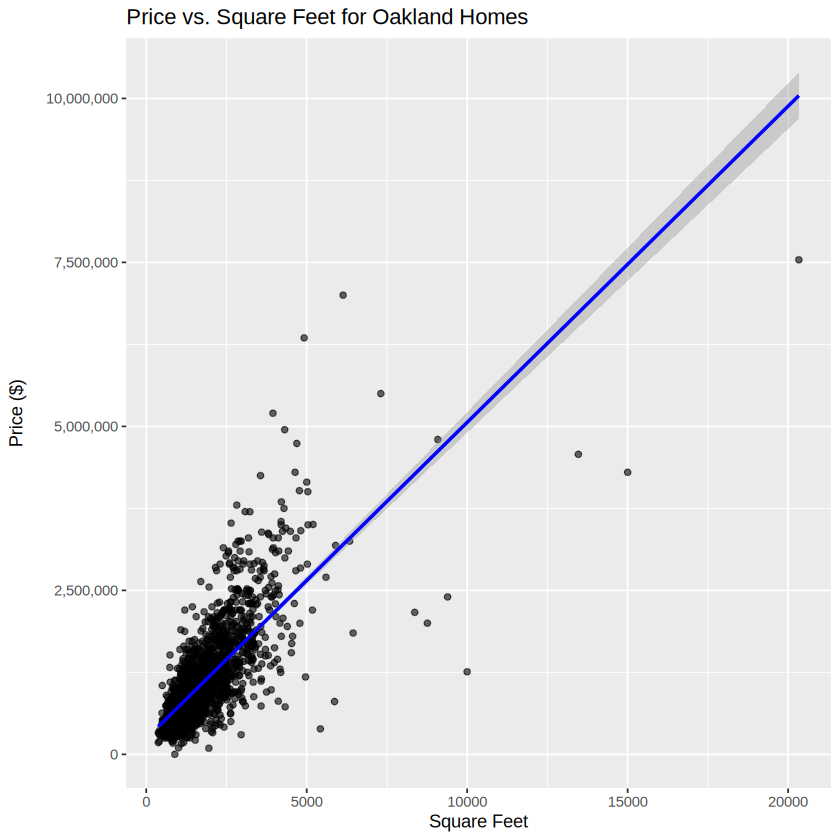

In [4]:
# Load libraries
library(tidyverse)

# Load the data
homes_df <- read_csv("data/oaklandredfin.csv", name_repair = 'universal')

homes_df <- homes_df %>%
  mutate(PRICE = as.numeric(PRICE) / 1e5) %>%   # divide by 100,000 instead of 2,000,000
  filter(!is.na(PRICE) & PRICE > 0)

# Filter only for Oakland
oakland_homes <- homes_df %>%
  filter(CITY == "Oakland")

# Run the linear regression
model <- lm(PRICE ~ SQUARE.FEET, data = oakland_homes)

# View summary of results
summary(model)

# Plot
ggplot(oakland_homes, aes(x = SQUARE.FEET, y = PRICE)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", color = "blue") +
  scale_y_continuous(
    labels = function(x) scales::comma(x * 1e5)  # rescale back to full dollar labels
  ) +
  labs(
    title = "Price vs. Square Feet for Oakland Homes",
    x = "Square Feet",
    y = "Price ($)"
  )


**QUESTION 2:** Run a simple linear regression taking the following form:
𝑆𝐴𝐿𝐸.𝑃𝑅𝐼𝐶𝐸 = β0 + β₁ 𝑆𝑄𝑈𝐴𝑅𝐸.𝐹𝐸𝐸𝑇 + 𝜖 Interpret β₁ and its statistical significance.

<span style="font-size:150%;color:green"> 
β₁ SQUARE.FEET = 0.0058720 → For every additional square foot of living space, the home’s price increases by about $587, on average, holding all else constant.
<br>
The p-value is 2.2e-16 (2×10−16=0.0000000000000002), which is very small highly statistically significant. In this context, this value suggests there is a very strong positive association between square footage and home price in Oakland.
</span>

New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR
  INFO ON PRICING)` ->
  `URL..SEE.https...www.redfin.com.buy.a.home.comparative.market.analysis.FOR.INFO.ON.PRICING.`
• `MLS#` -> `MLS.`
Rows: 2237 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): SALE.TYPE, SOLD.DATE, PROPERTY.TYPE, ADDRESS, CITY, STATE.OR.PROVI...
dbl (11): ZIP.OR.POSTAL.CODE, PRICE, BEDS, BATHS, SQUARE.FEET, LOT.SI


Call:
lm(formula = PRICE ~ SQUARE.FEET + BEDS + BATHS, data = homes_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-46.047  -2.414  -0.590   1.801  33.932 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.7305940  0.2530880   6.838 1.07e-11 ***
SQUARE.FEET  0.0057024  0.0002041  27.940  < 2e-16 ***
BEDS        -0.6816310  0.1232281  -5.531 3.61e-08 ***
BATHS        0.5789200  0.1766891   3.276  0.00107 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.716 on 1934 degrees of freedom
Multiple R-squared:  0.5779,	Adjusted R-squared:  0.5772 
F-statistic: 882.5 on 3 and 1934 DF,  p-value: < 2.2e-16


Regression equation:
PRICE = 1.731 + 0.006 * SQUARE.FEET + -0.682 * BEDS + 0.579 * BATHS


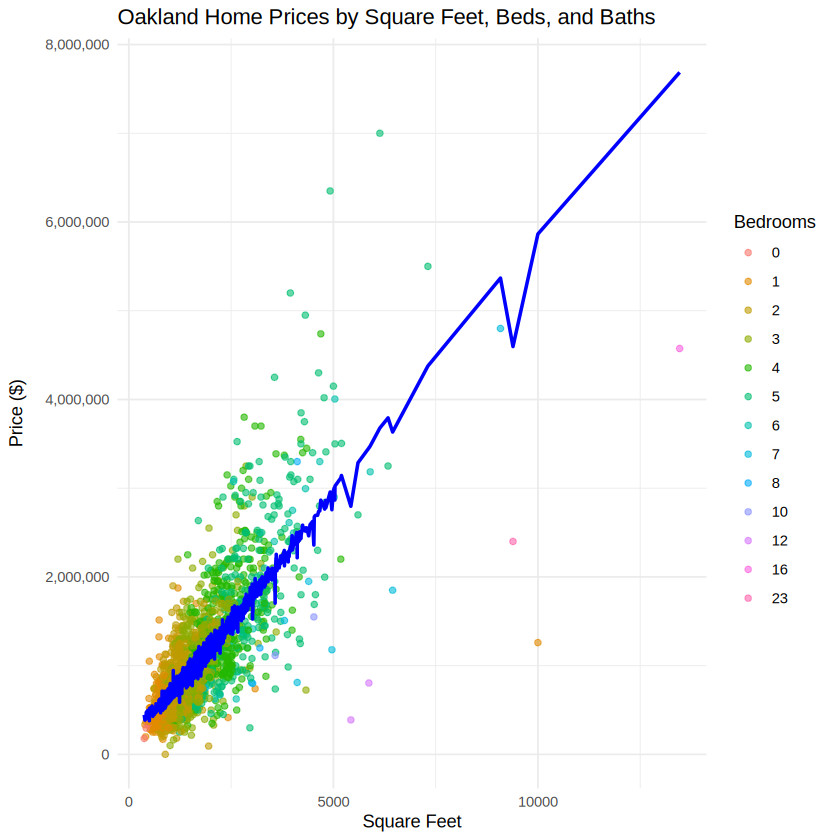

In [5]:
# Load libraries
library(tidyverse)

# Load the data
homes_df <- read_csv("data/oaklandredfin.csv", name_repair = 'universal')

# Clean and prepare the data
homes_df <- homes_df %>%
  mutate(
    PRICE = as.numeric(PRICE) / 1e5,      # convert to hundred-thousands
    BEDS = as.numeric(BEDS),
    BATHS = as.numeric(BATHS),
    SQUARE.FEET = as.numeric(SQUARE.FEET)
  ) %>%
  filter(
    !is.na(PRICE) & PRICE > 0,
    !is.na(SQUARE.FEET),
    !is.na(BEDS),
    !is.na(BATHS),
    CITY == "Oakland"
  )

# Run multiple regression
model <- lm(PRICE ~ SQUARE.FEET + BEDS + BATHS, data = homes_df)

# View summary
summary(model)

# Regression equation (in text)
cat("Regression equation:\nPRICE =",
    round(coef(model)[1], 3), "+",
    round(coef(model)[2], 3), "* SQUARE.FEET +",
    round(coef(model)[3], 3), "* BEDS +",
    round(coef(model)[4], 3), "* BATHS\n")

# Plot predicted vs actual prices, colored by number of beds
homes_df <- homes_df %>%
  mutate(predicted = predict(model, newdata = homes_df))

ggplot(homes_df, aes(x = SQUARE.FEET, y = PRICE, color = factor(BEDS))) +
  geom_point(alpha = 0.6) +
  geom_line(aes(y = predicted), color = "blue", linewidth = 1) +
  scale_y_continuous(labels = function(x) scales::comma(x * 1e5)) +
  labs(
    title = "Oakland Home Prices by Square Feet, Beds, and Baths",
    x = "Square Feet",
    y = "Price ($)",
    color = "Bedrooms"
  ) +
  theme_minimal()


**QUESTION 3:** Run a regression model with the additional explanatory variables of BEDS and BATHS (in addition to SQUARE.FEET). Write out the regression equation. What do you notice about the additional coefficients and how existing coefficients change?

<span style="font-size:150%;color:green"> 
<p>The regression equation after adding BEDS and BATHS is: 
PRICE= B0 + [# of square feet] × SQUARE.FEET + [# of beds] × BEDS + [# of baths] × BATHS. The cost per square feet changed by a very small amount (from 0.0058720 to 0.0058152)</p>
<span style="font-size:150%;color:green"></span>
<p>BEDS =  -1.5152935 -> If you increase the number of bedrooms by 1, while holding total square footage and number of bathrooms constant, the model predicts a $151,500 decrease in price. The p-value is 5.65e-05 (0.0000565), which means bedrooms are statistically significant because the number of bedrooms and square footage is related to the price.</p></span>
<span style="font-size:150%;color:green"> 
<p>BATHS = 1.6088622  -> Holding square footage and number of bedrooms constant, each additional bathroom increases price by about $160,900 on average. The p-value for this variable is 0.00201 which is statistically significant, but not as much as the BEDS variable is.</p></span>



In [6]:
library(tidyverse)

# Load the data
homes_df <- read_csv("data/oaklandredfin.csv", name_repair = 'universal')

# Clean and keep only Oakland
homes_df <- homes_df %>%
  mutate(
    PRICE        = as.numeric(PRICE) / 1e5,  # price in hundred-thousands
    BEDS         = as.numeric(BEDS),
    BATHS        = as.numeric(BATHS),
    SQUARE.FEET  = as.numeric(SQUARE.FEET)
  ) %>%
  filter(
    !is.na(PRICE) & PRICE > 0,
    !is.na(SQUARE.FEET),
    !is.na(BEDS),
    !is.na(BATHS),
    CITY == "Oakland"
  )

# Model 1: sqft only
model1 <- lm(PRICE ~ SQUARE.FEET, data = homes_df)

# Model 2: sqft + beds + baths
model2 <- lm(PRICE ~ SQUARE.FEET + BEDS + BATHS, data = homes_df)


New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR
  INFO ON PRICING)` ->
  `URL..SEE.https...www.redfin.com.buy.a.home.comparative.market.analysis.FOR.INFO.ON.PRICING.`
• `MLS#` -> `MLS.`
Rows: 2237 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): SALE.TYPE, SOLD.DATE, PROPERTY.TYPE, ADDRESS, CITY, STATE.OR.PROVI...
dbl (11): ZIP.OR.POSTAL.CODE, PRICE, BEDS, BATHS, SQUARE.FEET, LOT.SI

In [7]:
# install.packages("stargazer")  # if you haven't yet
library(stargazer)

stargazer(
  model1, model2,
  type = "text",   # use "latex" or "html" if you need those
  title = "Comparison of Models for Oakland Home Prices",
  dep.var.labels = "Price (hundred-thousands)",
  column.labels = c("Sqft only", "Sqft + Beds + Baths"),
  covariate.labels = c("Square feet", "Beds", "Baths"),
  keep.stat = c("n", "rsq", "adj.rsq", "f", "ser")
)



Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 





Comparison of Models for Oakland Home Prices
                                     Dependent variable:                 
                    -----------------------------------------------------
                                  Price (hundred-thousands)              
                             Sqft only             Sqft + Beds + Baths   
                                (1)                        (2)           
-------------------------------------------------------------------------
Square feet                  0.005***                   0.006***         
                             (0.0001)                   (0.0002)         
                                                                         
Beds                                                    -0.682***        
                                                         (0.123)         
                                                                         
Baths                                                   0.579***  

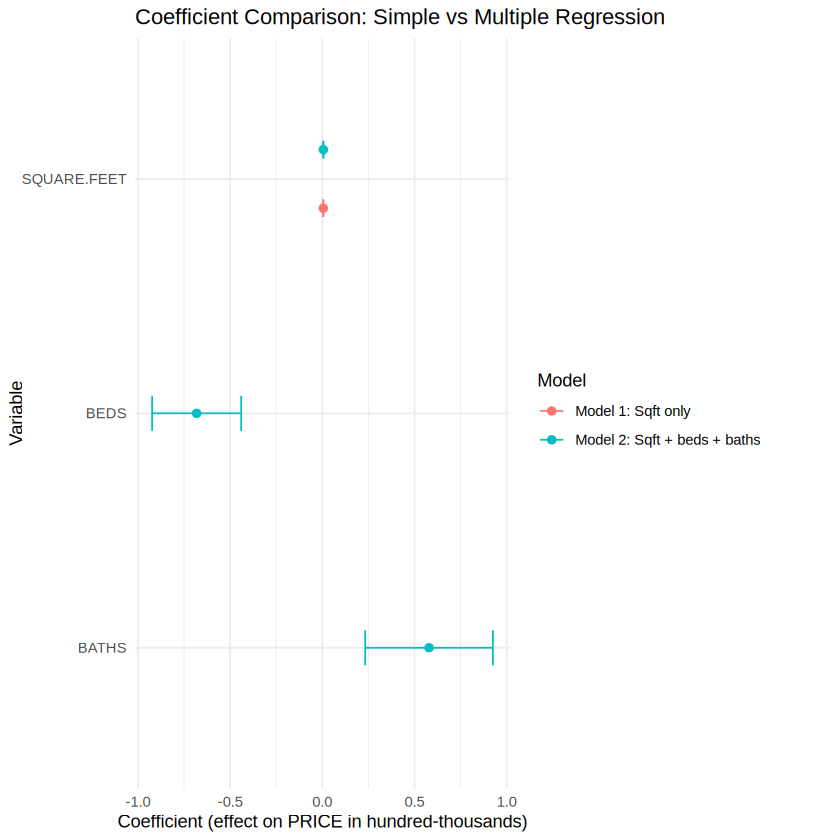

In [8]:
# install.packages("broom")  # if needed
library(broom)

coefs <- bind_rows(
  tidy(model1) %>% mutate(model = "Model 1: Sqft only"),
  tidy(model2) %>% mutate(model = "Model 2: Sqft + beds + baths")
) %>%
  filter(term != "(Intercept)")  # drop intercept for clarity

ggplot(coefs, aes(x = term, y = estimate, color = model)) +
  geom_point(position = position_dodge(width = 0.5), size = 2) +
  geom_errorbar(
    aes(ymin = estimate - 1.96 * std.error,
        ymax = estimate + 1.96 * std.error),
    position = position_dodge(width = 0.5),
    width = 0.15
  ) +
  coord_flip() +
  labs(
    title = "Coefficient Comparison: Simple vs Multiple Regression",
    x = "Variable",
    y = "Coefficient (effect on PRICE in hundred-thousands)",
    color = "Model"
  ) +
  theme_minimal()


In [9]:
library(ggplot2)
library(dplyr)
library(readr)
library(leaflet)
library(sf)
library(stringr)
library(lubridate)
library(htmltools)

# --- 1. Load redlining GeoJSON ---
oakland_sf <- st_read("data/oakland_redlining.geojson", quiet = TRUE)
oakland_sf_valid <- st_make_valid(oakland_sf)
oakland_label_points <- st_point_on_surface(oakland_sf_valid)

# --- 2. Load and filter house data ---
homes_df <- read_csv("data/oaklandredfin.csv")

oakland_homes <- homes_df %>%
  filter(tolower(CITY) == "oakland") %>%
  mutate(
    PRICE_CATEGORY = case_when(
      PRICE < 500000 ~ "Below $500K",
      PRICE >= 500000 & PRICE < 1000000 ~ "$501K - $999K",
      PRICE >= 1000000 & PRICE < 1500000 ~ "$1M - $1.49M",
      PRICE >= 1500000 ~ "Above $1.5M"
    ),
    COLOR = case_when(
      PRICE_CATEGORY == "Below $500K" ~ "blue",
      PRICE_CATEGORY == "$501K - $999K" ~ "gold",
      PRICE_CATEGORY == "$1M - $1.49M" ~ "purple",
      PRICE_CATEGORY == "Above $1.5M" ~ "red"
    )
  )

# --- 3. Load and clean crime data ---
crime_df <- read_csv("data/CrimeWatch_Maps_Past_90-Days_20251102.csv", show_col_types = FALSE)

crime_df_clean <- crime_df %>%
  filter(!is.na(Location), str_trim(Location) != "") %>%
  mutate(DATETIME = ymd_hms(DATETIME, quiet = TRUE)) %>%
  filter(!is.na(DATETIME)) %>%
  # Use today's date as reference (not Sys.time())
  filter(DATETIME >= (as_datetime(Sys.Date()) - days(14)))

crime_sf <- st_as_sf(crime_df_clean, wkt = "Location", crs = 4326, remove = FALSE) %>%
  mutate(
    LON = st_coordinates(.)[, 1],
    LAT = st_coordinates(.)[, 2]
  ) %>%
  filter(!is.na(LON) & !is.na(LAT))

# --- 4. Define HOLC and crime colors ---
holc_colors <- c("A" = "green", "B" = "blue", "C" = "yellow", "D" = "red")

crime_clean <- crime_sf %>%
  mutate(
    CRIME_CATEGORY = case_when(
      str_detect(toupper(CRIMETYPE), "ASSAULT|ROBBERY|HOMICIDE") ~ "Violent Crime",
      str_detect(toupper(CRIMETYPE), "BURGLARY|THEFT|VEHICLE") ~ "Property Crime",
      TRUE ~ "Other"
    ),
    CRIME_COLOR = case_when(
      CRIME_CATEGORY == "Violent Crime" ~ "red",
      CRIME_CATEGORY == "Property Crime" ~ "orange",
      TRUE ~ "gray"
    )
  )

# --- 5. Label text color for HOLC grades ---
oakland_label_points <- oakland_label_points %>%
  mutate(
    label_color = case_when(
      grade %in% c("B", "D") ~ "white",
      TRUE ~ "black"
    )
  )

# ============================
# 1️⃣ Redlining / HOLC only
# ============================
map_redlining <- leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  addPolygons(
    data = oakland_sf_valid,
    color = "black",
    weight = 1,
    fillColor = ~ifelse(!is.na(grade) & grade %in% names(holc_colors),
                        holc_colors[grade],
                        "gray"),
    fillOpacity = 0.55,
    popup = ~paste0("<b>HOLC Area:</b> ", label, "<br>",
                    "<b>Grade:</b> ", ifelse(is.na(grade), "No Grade", grade))
  ) %>%
  addLabelOnlyMarkers(
    data = oakland_label_points,
    label = ~grade,
    labelOptions = labelOptions(
      textsize = "14px",
      fontWeight = "bold",
      opacity = 0.9,
      textOnly = TRUE,
      style = list("color" = oakland_label_points$label_color)
    )
  ) %>%
  addLegend(
    position = "bottomleft",
    colors = c(holc_colors, "gray"),
    labels = c("A - BEST", "B - STILL DESIRABLE", "C - DECLINING", "D - HAZARDOUS", "No Grade"),
    title = "HOLC Redlining Grade"
  ) %>%
  setView(lng = -122.2711, lat = 37.8044, zoom = 12)

# ============================
# 2️⃣ Homes only
# ============================
map_homes <- leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  addCircleMarkers(
    data = oakland_homes,
    lng = ~LONGITUDE, lat = ~LATITUDE,
    radius = 8, color = "white", weight = 1,
    fillColor = ~COLOR, fillOpacity = 0.9,
    popup = ~paste0("<b>Price:</b> $", formatC(PRICE, format = "f", big.mark = ",", digits = 0),
                    "<br><b>Category:</b> ", PRICE_CATEGORY)
  ) %>%
  addLegend(
    position = "bottomright",
    colors = c("blue", "gold", "purple", "red"),
    labels = c("Below $500K", "$501K - $999K", "$1M - $1.49M", "Above $1.5M"),
    title = "Home Price Range"
  ) %>%
  setView(lng = -122.2711, lat = 37.8044, zoom = 12)

# ============================
# 3️⃣ Crimes only (Last 14 Days)
# ============================
map_crimes <- leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  addCircleMarkers(
    data = crime_clean,
    lng = ~LON, lat = ~LAT,
    radius = 3.5, color = "white", weight = 1,
    fillColor = ~CRIME_COLOR, fillOpacity = 0.9,
    popup = ~paste0("<b>Crime:</b> ", DESCRIPTION,
                    "<br><b>Type:</b> ", CRIMETYPE,
                    "<br><b>Date:</b> ", DATETIME,
                    "<br><b>Category:</b> ", CRIME_CATEGORY)
  ) %>%
  addLegend(
    position = "bottomright",
    colors = c("red", "orange", "gray"),
    labels = c("Violent Crime", "Property Crime", "Other"),
    title = "Crime Type (Last 14 Days)"
  ) %>%
  setView(lng = -122.2711, lat = 37.8044, zoom = 12)

# ============================
# 4️⃣ Target Stores in Oakland
# ============================
target_df <- read_csv("data/target.csv", show_col_types = FALSE)

oakland_targets <- target_df %>%
  filter(str_detect(str_to_lower(Address.County), "oakland|alameda")) %>%
  select(Name, Address.FormattedAddress, Address.Latitude, Address.Longitude, OperatingHours..timeFormat)

map_targets <- leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  addCircleMarkers(
    data = oakland_targets,
    lng = ~Address.Longitude,
    lat = ~Address.Latitude,
    radius = 12,
    color = "darkred",
    fillColor = "red",
    fillOpacity = 0.8,
    weight = 2,
    popup = ~paste0(
      "<b>Store Name:</b> ", Name, "<br>",
      "<b>Address:</b> ", Address.FormattedAddress, "<br>",
      "<b>Hours:</b> ", OperatingHours..timeFormat
    )
  ) %>%
  addLegend(
    position = "bottomright",
    colors = "red",
    labels = "Target Store",
    title = "Target Locations"
  ) %>%
  setView(lng = -122.2711, lat = 37.8044, zoom = 11)

# ============================
# 5️⃣ Combined Map (Dynamic Layers)
# ============================

holc_colors <- c("A" = "#1a9850", "B" = "#91cf60", "C" = "#fee08b", "D" = "#d73027")
home_price_colors <- c("blue", "gold", "purple", "red")
crime_colors <- c("red", "orange", "gray")

map_combined <- leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  
  addPolygons(
    data = oakland_sf_valid, group = "Redlining (HOLC)",
    color = "black", weight = 1,
    fillColor = ~ifelse(!is.na(grade) & grade %in% names(holc_colors),
                        holc_colors[grade],
                        "gray"),
    fillOpacity = 0.55,
    popup = ~paste0("<b>HOLC Area:</b> ", label,
                    "<br><b>Grade:</b> ", ifelse(is.na(grade), "No Grade", grade))
  ) %>%
  
  addCircleMarkers(
    data = oakland_homes, group = "Homes",
    lng = ~LONGITUDE, lat = ~LATITUDE,
    radius = 8, color = "white", weight = 1,
    fillColor = ~COLOR, fillOpacity = 0.9,
    popup = ~paste0("<b>Price:</b> $", formatC(PRICE, format = "f", big.mark = ",", digits = 0),
                    "<br><b>Category:</b> ", PRICE_CATEGORY)
  ) %>%
  
  addCircleMarkers(
    data = crime_clean, group = "Crimes (14 Days)",
    lng = ~LON, lat = ~LAT,
    radius = 3.5, color = "white", weight = 1,
    fillColor = ~CRIME_COLOR, fillOpacity = 0.9,
    popup = ~paste0("<b>Crime:</b> ", DESCRIPTION,
                    "<br><b>Type:</b> ", CRIMETYPE,
                    "<br><b>Date:</b> ", DATETIME,
                    "<br><b>Category:</b> ", CRIME_CATEGORY)
  ) %>%
  
  addCircleMarkers(
    data = oakland_targets, group = "Targets",
    lng = ~Address.Longitude, lat = ~Address.Latitude,
    radius = 12, color = "darkred", weight = 2,
    fillColor = "red", fillOpacity = 0.8,
    popup = ~paste0("<b>Store Name:</b> ", Name, "<br>",
                    "<b>Address:</b> ", Address.FormattedAddress, "<br>",
                    "<b>Hours:</b> ", OperatingHours..timeFormat)
  ) %>%
  
  addLayersControl(
    overlayGroups = c("Redlining (HOLC)", "Homes", "Crimes (14 Days)", "Targets"),
    options = layersControlOptions(collapsed = FALSE)
  ) %>%
  
  addLegend(
    position = "bottomleft",
    colors = c(holc_colors, "gray"),
    labels = c("A - BEST", "B - STILL DESIRABLE", "C - DECLINING", "D - HAZARDOUS", "No Grade"),
    title = "HOLC Redlining Grade"
  ) %>%
  addLegend(
    position = "bottomright",
    colors = home_price_colors,
    labels = c("Below $500K", "$501K - $999K", "$1M - $1.49M", "Above $1.5M"),
    title = "Home Price Range"
  ) %>%
  addLegend(
    position = "topright",
    colors = crime_colors,
    labels = c("Violent Crime", "Property Crime", "Other"),
    title = "Crime Type (Last 14 Days)"
  ) %>%
  
  setView(lng = -122.2711, lat = 37.8044, zoom = 12)

# --- View maps individually or together ---
map_redlining
map_homes
map_crimes
map_targets
map_combined


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE

Warning message:
“st_point_on_surface assumes attributes are constant over geometries”
Warning message in st_point_on_surface.sfc(st_geometry(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”
Rows: 2237 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): SALE TYPE, SOLD DATE, PROPERTY TYPE, ADDRESS, CITY, STATE OR PROVI...
dbl (11): ZIP OR POSTAL CODE, PRICE, BEDS, BATHS, SQUARE FEET, LOT SIZE, YEA...
lgl  (3): DAYS ON MARKET, NEXT OPEN HOUSE START TIME, NEXT OPEN HOUSE END TIME

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


HTML widgets cannot be represented in plain text (need html)

HTML widgets cannot be represented in plain text (need html)

HTML widgets cannot be represented in plain text (need html)

HTML widgets cannot be represented in plain text (need html)

HTML widgets cannot be represented in plain text (need html)

**QUESTION 3:** Based on your knowledge of the city, what other variable(s) would you include to better predict residential home prices? Go ahead and collect the data for (a small sample of) your homes. Interpret your additional results and use them appropriately. You can also consider different models or model specifications. Argued for the importance of your additional analysis for identifying investment opportunities. Be creative!


<p style="font-size:150%; color:green;">
  Redlining was a discriminatory practice in the United States where banks, insurance companies, 
  and the government refused to offer loans, mortgages, or insurance to people living in certain 
  neighborhoods — mostly communities of color, especially Black neighborhoods.
</p>

<p style="font-size:150%; color:green;">
  The term comes from the 1930s, when the federal government created maps to assess the risk of 
  giving home loans in different areas. Lenders would literally draw red lines around these 
  neighborhoods and deny financial services to people living there, regardless of their individual 
  creditworthiness. Redlining had long-lasting effects:
</p>

<ul style="font-size:150%; color:green;">
  <li>
    It prevented families of color from buying homes, which is one of the main ways Americans build wealth.
  </li>
  <li>
    It led to disinvestment in redlined neighborhoods — fewer jobs, worse schools, and poor infrastructure.
  </li>
  <li>
    It contributed to racial segregation and economic inequality that 
    <b style="color:red;">evidently</b> still exists today.
  </li>
</ul>


</span>


# BART proximity calc
Compute distance from each Redfin listing to the nearest BART station, add distance_to_bart_miles and within_0_5_miles_bart.


In [10]:
# BART proximity analysis (R)
# - Clean listings and station data
# - Compute nearest BART distance
# - Add distance_to_bart_miles and within_0_5_miles_bart

suppressPackageStartupMessages({
  library(tidyverse)
  library(sf)
  library(xml2)
  library(purrr)
})

sf::sf_use_s2(TRUE)

# Ensure homes_df exists; otherwise read CSV
if (!exists("homes_df")) {
  homes_df <- readr::read_csv("data/oaklandredfin.csv", show_col_types = FALSE)
}

# Clean: coerce key fields and drop obvious junk (missing coords)
homes_df <- homes_df %>%
  mutate(
    LATITUDE = suppressWarnings(as.numeric(LATITUDE)),
    LONGITUDE = suppressWarnings(as.numeric(LONGITUDE)),
    PRICE = suppressWarnings(as.numeric(PRICE))
  )

homes_with_coords_idx <- which(!is.na(homes_df$LATITUDE) & !is.na(homes_df$LONGITUDE))
if (length(homes_with_coords_idx) == 0) {
  stop("No listings with valid LATITUDE/LONGITUDE found.")
}

homes_sf <- sf::st_as_sf(
  homes_df[homes_with_coords_idx, ],
  coords = c("LONGITUDE", "LATITUDE"), crs = 4326, remove = FALSE
)

# Load BART stations from KMZ (doc.kml inside)
kmz_path <- if (file.exists("data/BART_Stations_2025.kmz")) "data/BART_Stations_2025.kmz" else "402/data/BART_Stations_2025.kmz"
.tmpdir <- tempfile("bart_kmz_")
dir.create(.tmpdir, showWarnings = FALSE)
utils::unzip(kmz_path, files = "doc.kml", exdir = .tmpdir, overwrite = TRUE)

kml <- xml2::read_xml(file.path(.tmpdir, "doc.kml"))

# Extract station names and coordinates using namespace-agnostic XPath
pls <- xml2::xml_find_all(kml, ".//*[local-name()='Placemark']")

get_one <- function(pm) {
  nm <- xml2::xml_text(xml2::xml_find_first(pm, ".//*[local-name()='name']"))
  ct <- xml2::xml_text(xml2::xml_find_first(pm, ".//*[local-name()='Point']/*[local-name()='coordinates']"))
  if (is.na(ct) || is.na(nm) || is.null(ct) || ct == "") return(NULL)
  pts <- strsplit(trimws(ct), ",")[[1]]
  lon <- suppressWarnings(as.numeric(pts[1]))
  lat <- suppressWarnings(as.numeric(pts[2]))
  if (is.na(lon) || is.na(lat)) return(NULL)
  tibble::tibble(station_name = nm, longitude = lon, latitude = lat)
}

stations_df <- purrr::map(pls, get_one) %>%
  dplyr::bind_rows() %>%
  filter(!is.na(longitude), !is.na(latitude)) %>%
  distinct(station_name, longitude, latitude, .keep_all = TRUE)

stations_sf <- sf::st_as_sf(stations_df, coords = c("longitude", "latitude"), crs = 4326, remove = FALSE)

# Compute nearest station distance (miles)
nearest_idx <- sf::st_nearest_feature(homes_sf, stations_sf)
nearest_dist_m <- sf::st_distance(homes_sf, stations_sf[nearest_idx, ], by_element = TRUE)
nearest_dist_miles <- as.numeric(nearest_dist_m) / 1609.344

# Attach back to full homes_df
.dist_full <- rep(NA_real_, nrow(homes_df))
.dist_full[homes_with_coords_idx] <- nearest_dist_miles

homes_df <- homes_df %>%
  mutate(
    distance_to_bart_miles = .dist_full,
    within_0_5_miles_bart = as.integer(!is.na(distance_to_bart_miles) & distance_to_bart_miles <= 0.5)
  )

# Inspection outputs
message("BART stations parsed: ", nrow(stations_sf))
message("Listings with coordinates: ", length(homes_with_coords_idx))

# Show columns inferred from homes_df and a sample of stations
print(head(dplyr::select(homes_df,
  ADDRESS, CITY, LATITUDE, LONGITUDE, PRICE, distance_to_bart_miles, within_0_5_miles_bart
)))
print(head(dplyr::select(stations_df, station_name, latitude, longitude)))


BART stations parsed: 52

Listings with coordinates: 2237



# A tibble: 6 × 7
  ADDRESS               CITY    LATITUDE LONGITUDE  PRICE distance_to_bart_miles
  <chr>                 <chr>      <dbl>     <dbl>  <dbl>                  <dbl>
1 3369 Arkansas St      Oakland     37.8     -122. 6.17e5                  1.60 
2 6846 Saroni Dr        Oakland     37.8     -122. 7.6 e5                  2.90 
3 1004 39th St          Emeryv…     37.8     -122. 2.62e5                  0.553
4 200 Caldecott Ln #106 Oakland     37.9     -122. 3.60e5                  1.89 
5 5101 McDonell Ave     Oakland     37.8     -122. 2.5 e5                  2.64 
6 71 Norman Ln          Oakland     37.8     -122. 1.02e6                  0.997
# ℹ 1 more variable: within_0_5_miles_bart <int>
# A tibble: 6 × 3
  station_name             latitude longitude
  <chr>                       <dbl>     <dbl>
1 Milpitas                     37.4     -122.
2 Berryessa/North San José     37.4     -122.
3 Civic Center/UN Plaza        37.8     -122.
4 Concord                      38.0  

In [11]:
names(homes_df)
summary(homes_df$distance_to_bart_miles)
table(homes_df$within_0_5_miles_bart)


[1] "SALE TYPE"                                                                                  
 [2] "SOLD DATE"                                                                                  
 [3] "PROPERTY TYPE"                                                                              
 [4] "ADDRESS"                                                                                    
 [5] "CITY"                                                                                       
 [6] "STATE OR PROVINCE"                                                                          
 [7] "ZIP OR POSTAL CODE"                                                                         
 [8] "PRICE"                                                                                      
 [9] "BEDS"                                                                                       
[10] "BATHS"                                                                                      
[11] "LOCATION"                                                                                   
[12] "SQUARE FEET"                                                                                
[13] "LOT SIZE"                                                                                   
[14] "YEAR BUILT"                                                                                 
[15] "DAYS ON MARKET"                                                                             
[16] "$/SQUARE FEET"                                                                              
[17] "HOA/MONTH"                                                                                  
[18] "STATUS"                                                                                     
[19] "NEXT OPEN HOUSE START TIME"                                                                 
[20] "NEXT OPEN HOUSE END TIME"                                                                   
[21] "URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING)"
[22] "SOURCE"                                                                                     
[23] "MLS#"                                                                                       
[24] "FAVORITE"                                                                                   
[25] "INTERESTED"                                                                                 
[26] "LATITUDE"                                                                                   
[27] "LONGITUDE"                                                                                  
[28] "distance_to_bart_miles"                                                                     
[29] "within_0_5_miles_bart"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.09283 0.77284 1.33245 1.49911 2.13287 3.84201 


   0    1 
2008  229 

In [12]:
set.seed(402)  # optional, for reproducible sample
homes_df %>%
  dplyr::sample_n(10) %>%
  dplyr::select(
    ADDRESS, CITY, LATITUDE, LONGITUDE, PRICE,
    distance_to_bart_miles, within_0_5_miles_bart
  )


ADDRESS,CITY,LATITUDE,LONGITUDE,PRICE,distance_to_bart_miles,within_0_5_miles_bart
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2415 Scenic Ave,Oakland,37.80195,-122.2114,820000,1.9955347,0
5887 Margarido Dr,Oakland,37.84466,-122.2421,2680000,0.5049514,0
38 Windward Hl,Oakland,37.85286,-122.2271,1700000,1.4334272,0
5 Captains Cv,Oakland,37.85610,-122.2260,1700000,1.5891643,0
1669 13th St,Oakland,37.81151,-122.2965,350000,0.4631934,1
103 Alvarado Rd,Berkeley,37.85789,-122.2396,3200000,1.1122170,0
9709 Coral Rd,Oakland,37.73170,-122.1909,275000,1.4524828,0
4392 Terrabella Pl,Oakland,37.79595,-122.1785,1065000,2.8883962,0
6296 Rocky Point Ct,Oakland,37.77862,-122.1623,900000,2.5535283,0


# Quality School proximity calc
Compute distance from each Redfin listing to the nearest quality school station, add distance_to_school_miles and within_2_miles_school.


In [13]:
## School quality proximity (CDE data → homes_df)
install.packages("geosphere")
library(tidyverse)
library(geosphere)


# <-- Add this line (or run it again if you already had it)
data_dir <- "data"


# Helper: pick the first existing column name from a set of candidates
choose_col <- function(df, candidates) {
  found <- candidates[candidates %in% names(df)]
  if (length(found) == 0) {
    stop("None of these columns found: ", paste(candidates, collapse = ", "))
  }
  found[[1]]
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘geosphere’


The following object is masked from ‘package:htmltools’:

    span




In [14]:
pubschls_raw <- readr::read_tsv(
  file.path(data_dir, "pubschls.txt"),
  col_types = readr::cols(.default = "c")
)

ela_raw <- readr::read_tsv(
  file.path(data_dir, "eladownload2024.txt"),
  col_types = readr::cols(.default = "c")
)

math_raw <- readr::read_tsv(
  file.path(data_dir, "mathdownload2024.txt"),
  col_types = readr::cols(.default = "c")
)



In [15]:
# Resolve key columns
county_col   <- choose_col(pubschls_raw, c("County", "COUNTY"))
city_col     <- choose_col(pubschls_raw, c("City", "CITY"))
status_col   <- choose_col(pubschls_raw, c("StatusType", "Status", "STATUSTYPE"))
cds_col      <- choose_col(pubschls_raw, c("CDSCode", "CDS", "cds", "CDS_CODE"))
district_col <- choose_col(pubschls_raw, c("District", "DistrictName", "DISTRICT", "DistName"))
school_col   <- choose_col(pubschls_raw, c("School", "SchoolName", "SCHOOL", "SchName"))
street_col   <- choose_col(pubschls_raw, c("Street", "Street1", "Street_Name", "PhysicalStreet"))
zip_col      <- choose_col(pubschls_raw, c("Zip", "ZIP", "ZipCode", "Zipcode", "PhysicalZip"))

# OPTIONAL: try to find a "type" column if it exists
type_candidates <- names(pubschls_raw)[
  stringr::str_detect(names(pubschls_raw), regex("type", ignore_case = TRUE))
]
type_col <- if (length(type_candidates) > 0) type_candidates[[1]] else NA_character_

charter_candidates <- c("Charter", "CharterYN", "CharterFlag", "CharterS")
charter_match <- charter_candidates[charter_candidates %in% names(pubschls_raw)]
charter_col <- if (length(charter_match) > 0) charter_match[[1]] else NA_character_

lat_candidates <- c("Latitude", "LATITUDE", "Lat")
lon_candidates <- c("Longitude", "LONGITUDE", "Lon")

lat_match <- lat_candidates[lat_candidates %in% names(pubschls_raw)]
lon_match <- lon_candidates[lon_candidates %in% names(pubschls_raw)]

lat_col <- if (length(lat_match) > 0) lat_match[[1]] else NA_character_
lon_col <- if (length(lon_match) > 0) lon_match[[1]] else NA_character_

# Base cleaning: filter Alameda / Oakland / Active and standardize fields
pubschls_oakland <- pubschls_raw %>%
  mutate(
    county     = str_trim(.data[[county_col]]),
    city_raw   = str_trim(.data[[city_col]]),
    status_raw = str_trim(.data[[status_col]])
  ) %>%
  filter(
    str_to_upper(county) == "ALAMEDA",
    str_to_upper(city_raw) == "OAKLAND",
    str_to_upper(status_raw) == "ACTIVE"
  ) %>%
  mutate(
    cds_code      = str_pad(str_trim(.data[[cds_col]]), width = 14, side = "left", pad = "0"),
    district_name = .data[[district_col]] %>% str_squish() %>% str_to_title(),
    school_name   = .data[[school_col]]   %>% str_squish() %>% str_to_title(),
    street        = .data[[street_col]]   %>% str_squish() %>% str_to_title(),
    city          = city_raw %>% str_squish() %>% str_to_title(),
    zip_code      = .data[[zip_col]] %>% str_extract("\\d{5}"),
    school_type   = if (!is.na(type_col)) .data[[type_col]] else NA_character_
  )

# Charter flag: handle presence/absence of charter column safely
if (!is.na(charter_col)) {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(
      charter_flag = case_when(
        str_to_upper(str_trim(.data[[charter_col]])) %in% c("Y", "YES", "CHARTER") ~ 1L,
        str_trim(.data[[charter_col]]) == "" ~ NA_integer_,
        TRUE ~ 0L
      )
    )
} else {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(charter_flag = NA_integer_)
}

# Latitude / longitude (if present)
if (!is.na(lat_col)) {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(latitude = suppressWarnings(as.numeric(.data[[lat_col]])))
} else {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(latitude = NA_real_)
}

if (!is.na(lon_col)) {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(longitude = suppressWarnings(as.numeric(.data[[lon_col]])))
} else {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(longitude = NA_real_)
}

# Final column selection and de-dup
pubschls_oakland <- pubschls_oakland %>%
  select(
    cds_code,
    district_name,
    school_name,
    street,
    city,
    zip_code,
    school_type,
    charter_flag,
    latitude,
    longitude
  ) %>%
  distinct(cds_code, .keep_all = TRUE)

pubschls_oakland %>% head()

cds_code,district_name,school_name,street,city,zip_code,school_type,charter_flag,latitude,longitude
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
01100170112607,Alameda County Office Of Education,Envision Academy For Arts & Technology,1515 Webster Street,Oakland,94612,Active,1,37.80452,-122.2682
01100170114363,Alameda County Office Of Education,American Indian Public Charter School Ii,171 12th Street,Oakland,94607,Active,1,37.80037,-122.2655
01100170123968,Alameda County Office Of Education,Community School For Creative Education,2111 International Boulevard,Oakland,94606,Active,1,37.78465,-122.2386
01100170124172,Alameda County Office Of Education,Yu Ming Charter,2501 Chestnut Street,Oakland,94607,Active,1,37.81823,-122.2823
01100170126748,Alameda County Office Of Education,Lps Oakland R & D Campus,"8601 Macarthur Boulevard, Building 100",Oakland,94605,Active,1,37.75954,-122.1629
01100170129403,Alameda County Office Of Education,Epic Charter,1045 Derby Avenue,Oakland,94601,Active,0,37.77705,-122.2296


In [16]:
clean_dashboard_subject <- function(df_raw, subject_prefix) {
  cds_col         <- choose_col(df_raw, c("CDSCode", "CDS", "cds"))
  rtype_col       <- choose_col(df_raw, c("rtype", "RType"))
  student_col     <- choose_col(df_raw, c("studentgroup", "StudentGroup", "student_group"))
  currstatus_col  <- choose_col(df_raw, c("currstatus", "CurrStatus"))
  statuslevel_col <- choose_col(df_raw, c("statuslevel", "StatusLevel"))
  color_col       <- choose_col(df_raw, c("color", "Color"))
  
  level_to_label <- c(
    `1` = "Very Low / Red",
    `2` = "Low / Orange",
    `3` = "Medium / Yellow",
    `4` = "High / Green",
    `5` = "Very High / Blue"
  )
  
  df_raw %>%
    mutate(
      rtype        = str_to_upper(str_trim(.data[[rtype_col]])),
      studentgroup = str_to_upper(str_trim(.data[[student_col]]))
    ) %>%
    filter(
      rtype == "S",
      studentgroup == "ALL"
    ) %>%
    mutate(
      cds_code = str_pad(str_trim(.data[[cds_col]]), width = 14, side = "left", pad = "0"),
      !!paste0(subject_prefix, "_distance") := suppressWarnings(as.numeric(.data[[currstatus_col]])),
      !!paste0(subject_prefix, "_statuslevel") := suppressWarnings(as.numeric(.data[[statuslevel_col]])),
      !!paste0(subject_prefix, "_color_code") := str_trim(.data[[color_col]]),
      !!paste0(subject_prefix, "_status_label") :=
        recode(as.character(.data[[statuslevel_col]]), !!!level_to_label)
    ) %>%
    select(
      cds_code,
      starts_with(paste0(subject_prefix, "_"))
    ) %>%
    distinct(cds_code, .keep_all = TRUE)
}

ela_clean  <- clean_dashboard_subject(ela_raw,  "ela")
math_clean <- clean_dashboard_subject(math_raw, "math")

ela_clean %>% head()
math_clean %>% head()

cds_code,ela_distance,ela_statuslevel,ela_color_code,ela_status_label
<chr>,<dbl>,<dbl>,<chr>,<chr>
01100170112607,-84.8,1,1,Very Low / Red
01100170123968,-82.8,1,1,Very Low / Red
01100170124172,83.8,5,4,Very High / Blue
01100170125567,-34.3,2,2,Low / Orange
01100170130401,NA,0,0,0
01100170130419,-218.3,1,0,Very Low / Red


cds_code,math_distance,math_statuslevel,math_color_code,math_status_label
<chr>,<dbl>,<dbl>,<chr>,<chr>
01100170112607,-165.1,1,1,Very Low / Red
01100170123968,-114.4,1,1,Very Low / Red
01100170124172,99.5,5,4,Very High / Blue
01100170125567,-63.3,2,3,Low / Orange
01100170130401,NA,0,0,0
01100170130419,-259.3,1,0,Very Low / Red


In [17]:
# Merge math + ELA at school level
school_perf <- math_clean %>%
  full_join(ela_clean, by = "cds_code")

# Continuous index: average of math_distance and ela_distance
school_perf <- school_perf %>%
  mutate(
    school_quality_distance = {
      dist_mat <- select(., math_distance, ela_distance) %>%
        mutate(across(everything(), as.numeric)) %>%
        as.matrix()
      
      row_mean <- rowMeans(dist_mat, na.rm = TRUE)
      # if both NA → rowMeans gives NaN, fix that
      both_na <- apply(is.na(dist_mat), 1, all)
      row_mean[both_na] <- NA_real_
      row_mean
    }
  )

# Categorical index: rounded average of math_statuslevel and ela_statuslevel
school_perf <- school_perf %>%
  mutate(
    school_quality_level = {
      lvl_mat <- select(., math_statuslevel, ela_statuslevel) %>%
        mutate(across(everything(), as.numeric)) %>%
        as.matrix()
      
      lvl_mean <- rowMeans(lvl_mat, na.rm = TRUE)
      both_na <- apply(is.na(lvl_mat), 1, all)
      lvl_mean[both_na] <- NA_real_
      as.integer(round(lvl_mean))
    }
  )

# Optional label for school_quality_level
level_to_label <- c(
  `1` = "Very Low / Red",
  `2` = "Low / Orange",
  `3` = "Medium / Yellow",
  `4` = "High / Green",
  `5` = "Very High / Blue"
)

school_perf <- school_perf %>%
  mutate(
    school_quality_label = recode(as.character(school_quality_level), !!!level_to_label)
  )

# Join onto Oakland schools
oakland_schools_perf <- pubschls_oakland %>%
  left_join(school_perf, by = "cds_code")

oakland_schools_perf %>% head()


cds_code,district_name,school_name,street,city,zip_code,school_type,charter_flag,latitude,longitude,⋯,math_statuslevel,math_color_code,math_status_label,ela_distance,ela_statuslevel,ela_color_code,ela_status_label,school_quality_distance,school_quality_level,school_quality_label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<chr>
01100170112607,Alameda County Office Of Education,Envision Academy For Arts & Technology,1515 Webster Street,Oakland,94612,Active,1,37.80452,-122.2682,⋯,1,1,Very Low / Red,-84.8,1,1,Very Low / Red,-124.95,1,Very Low / Red
01100170114363,Alameda County Office Of Education,American Indian Public Charter School Ii,171 12th Street,Oakland,94607,Active,1,37.80037,-122.2655,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
01100170123968,Alameda County Office Of Education,Community School For Creative Education,2111 International Boulevard,Oakland,94606,Active,1,37.78465,-122.2386,⋯,1,1,Very Low / Red,-82.8,1,1,Very Low / Red,-98.60,1,Very Low / Red
01100170124172,Alameda County Office Of Education,Yu Ming Charter,2501 Chestnut Street,Oakland,94607,Active,1,37.81823,-122.2823,⋯,5,4,Very High / Blue,83.8,5,4,Very High / Blue,91.65,5,Very High / Blue
01100170126748,Alameda County Office Of Education,Lps Oakland R & D Campus,"8601 Macarthur Boulevard, Building 100",Oakland,94605,Active,1,37.75954,-122.1629,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
01100170129403,Alameda County Office Of Education,Epic Charter,1045 Derby Avenue,Oakland,94601,Active,0,37.77705,-122.2296,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [18]:
q75 <- oakland_schools_perf %>%
  filter(!is.na(school_quality_distance)) %>%
  pull(school_quality_distance) %>%
  as.numeric() %>%
  quantile(probs = 0.75, na.rm = TRUE)

oakland_schools_perf <- oakland_schools_perf %>%
  mutate(
    is_quality_school =
      !is.na(school_quality_distance) &
      school_quality_distance >= q75 &
      !is.na(school_quality_level) &
      school_quality_level >= 4
  )



In [19]:
library(dplyr)
library(tidyr)

# Haversine helper (only needs to be defined once per kernel)
haversine_miles <- function(lat1, lon1, lat2, lon2) {
  rad <- pi / 180
  lat1 <- lat1 * rad
  lon1 <- lon1 * rad
  lat2 <- lat2 * rad
  lon2 <- lon2 * rad
  
  dlat <- lat2 - lat1
  dlon <- lon2 - lon1
  
  a <- sin(dlat / 2)^2 + cos(lat1) * cos(lat2) * sin(dlon / 2)^2
  c <- 2 * asin(pmin(1, sqrt(a)))
  
  earth_radius_miles <- 3958.8
  earth_radius_miles * c
}

# Home lat/lon columns
lat_home_col <- choose_col(homes_df, c("LATITUDE", "Latitude", "lat", "Lat"))
lon_home_col <- choose_col(homes_df, c("LONGITUDE", "Longitude", "lon", "Lon", "lng"))

# Use only strict "quality" schools with valid coords
schools_for_dist <- oakland_schools_perf %>%
  filter(
    is_quality_school,
    !is.na(latitude),
    !is.na(longitude)
  ) %>%
  transmute(
    cds_code,
    school_name,
    school_lat = as.numeric(latitude),
    school_lon = as.numeric(longitude),
    school_quality_distance,
    school_quality_level
  )

if (nrow(schools_for_dist) == 0) {
  warning("No quality schools with valid latitude/longitude; skipping distance features.")
} else {
  # 1) Add an index to homes
  homes_with_idx <- homes_df %>%
    mutate(home_idx = dplyr::row_number())
  
  # 2) Cross join homes × quality schools and compute distances
  pairs <- homes_with_idx %>%
    transmute(
      home_idx,
      home_lat = as.numeric(.data[[lat_home_col]]),
      home_lon = as.numeric(.data[[lon_home_col]])
    ) %>%
    tidyr::crossing(schools_for_dist) %>%
    mutate(
      distance_to_quality_school_miles = haversine_miles(
        home_lat, home_lon,
        school_lat, school_lon
      )
    )
  
  # 3) Nearest quality school per home
  nearest_quality <- pairs %>%
    group_by(home_idx) %>%
    slice_min(distance_to_quality_school_miles, n = 1, with_ties = FALSE) %>%
    ungroup()
  
  # 4) Join back onto homes_df and create the 2-mile flag
  homes_df <- homes_with_idx %>%
    left_join(
      nearest_quality %>%
        select(
          home_idx,
          distance_to_quality_school_miles,
          nearest_quality_school_name             = school_name,
          nearest_quality_school_quality_distance = school_quality_distance,
          nearest_quality_school_quality_level    = school_quality_level
        ),
      by = "home_idx"
    ) %>%
    mutate(
      within_2_miles_quality_school = if_else(
        !is.na(distance_to_quality_school_miles) &
          distance_to_quality_school_miles <= 2,
        1L, 0L
      )
    ) %>%
    select(-home_idx)
}


In [20]:
names(homes_df)[grepl("quality_school", names(homes_df))]

[1] "distance_to_quality_school_miles"       
[2] "nearest_quality_school_name"            
[3] "nearest_quality_school_quality_distance"
[4] "nearest_quality_school_quality_level"   
[5] "within_2_miles_quality_school"

In [21]:
homes_df <- homes_df %>%
  mutate(
    within_0_5_mile_quality_school = if_else(
      !is.na(distance_to_quality_school_miles) &
        distance_to_quality_school_miles <= 0.5,
      1L, 0L
    )
  )


In [22]:
homes_df %>%
  summarise(
    n_homes                     = n(),
    pct_within_0_5_mile_quality = mean(within_0_5_mile_quality_school == 1, na.rm = TRUE) * 100
  )

set.seed(123)
homes_df %>%
  select(
    ADDRESS = `ADDRESS`,
    `ZIP OR POSTAL CODE`,
    distance_to_quality_school_miles,
    within_0_5_mile_quality_school,
    nearest_quality_school_name
  ) %>%
  slice_sample(n = 10)


n_homes,pct_within_0_5_mile_quality
<int>,<dbl>
2237,27.8945


ADDRESS,ZIP OR POSTAL CODE,distance_to_quality_school_miles,within_0_5_mile_quality_school,nearest_quality_school_name
<chr>,<dbl>,<dbl>,<int>,<chr>
402 Hiller Dr,94618,0.9348404,0,Chabot Elementary
1116 16th St,94607,0.5112752,0,Yu Ming Charter
2033 Harrington Ave,94601,1.3634555,0,Downtown Charter Academy
6258 Boulder Ln #4801,94605,1.2108160,0,Oakland Unity High
1009 Winsor Ave,94610,0.6422999,0,Crocker Highlands Elementary
4614 Rockingham Ct,94619,1.4272076,0,Oakland Unity High
868 44th St,94608,1.2106267,0,Yu Ming Charter
9057 Skyline Blvd,94611,0.8712733,0,Joaquin Miller Elementary
6907 Chambers Dr,94611,0.6811770,0,Thornhill Elementary


In [23]:
library(dplyr)

set.seed(432)  # optional, just for reproducibility

homes_sample <- homes_df %>%
  # grab some core listing fields + all the school-quality stuff
  select(
    ADDRESS                = any_of("ADDRESS"),
    CITY                   = any_of("CITY"),
    `ZIP OR POSTAL CODE`,
    PRICE                  = any_of("PRICE"),
    LATITUDE               = any_of("LATITUDE"),
    LONGITUDE              = any_of("LONGITUDE"),
    distance_to_quality_school_miles,
    within_2_miles_quality_school,
    nearest_quality_school_name,
    nearest_quality_school_quality_distance,
    nearest_quality_school_quality_level,
    # if you added nearest-any-school columns, these will show too:
    nearest_school_distance_miles  = any_of("nearest_school_distance_miles"),
    nearest_school_name            = any_of("nearest_school_name"),
    nearest_school_quality_distance = any_of("nearest_school_quality_distance"),
    nearest_school_quality_level    = any_of("nearest_school_quality_level"),
    nearest_school_is_quality       = any_of("nearest_school_is_quality")
  ) %>%
  slice_sample(n = 5)

homes_sample


ADDRESS,CITY,ZIP OR POSTAL CODE,PRICE,LATITUDE,LONGITUDE,distance_to_quality_school_miles,within_2_miles_quality_school,nearest_quality_school_name,nearest_quality_school_quality_distance,nearest_quality_school_quality_level
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>
10127 Dante Ave,Oakland,94603,400000,37.74445,-122.1583,0.4812861,1,Francophone Charter School Of Oakland,10.10,4
622 Carlston Ave,Oakland,94610,2850000,37.81038,-122.2321,0.2667199,1,Crocker Highlands Elementary,48.25,5
630 Thomas L Berkley Way #713,Oakland,94612,615000,37.81022,-122.2724,0.7545721,1,Lincoln Elementary,27.60,4
2226 19th Ave,Oakland,94606,582500,37.79261,-122.2348,0.8282855,1,Edna Brewer Middle,-3.85,4
2830 Ritchie St,Oakland,94605,450000,37.76483,-122.1658,1.0411490,1,Francophone Charter School Of Oakland,10.10,4


In [24]:
oakland_schools_perf %>%
  count(is_quality_school)


is_quality_school,n
<lgl>,<int>
FALSE,110
TRUE,17


In [25]:
oakland_schools_perf %>%
  summarise(
    n_schools                = sum(!is.na(school_quality_distance)),
    q25                      = quantile(school_quality_distance, 0.25, na.rm = TRUE),
    q50                      = quantile(school_quality_distance, 0.50, na.rm = TRUE),
    q75                      = quantile(school_quality_distance, 0.75, na.rm = TRUE),
    max_quality_distance     = max(school_quality_distance, na.rm = TRUE)
  )


n_schools,q25,q50,q75,max_quality_distance
<int>,<dbl>,<dbl>,<dbl>,<dbl>
108,-113.875,-83.05,-39.05,91.65


In [26]:
homes_df %>%
  summarise(
    n_homes                 = n(),
    pct_within_2_miles      = mean(within_2_miles_quality_school == 1, na.rm = TRUE) * 100,
    pct_within_1_5_miles    = mean(distance_to_quality_school_miles <= 1.5, na.rm = TRUE) * 100,
    pct_within_1_mile       = mean(distance_to_quality_school_miles <= 1, na.rm = TRUE) * 100,
    pct_within_0_5_mile     = mean(distance_to_quality_school_miles <= 0.5, na.rm = TRUE) * 100
  )


n_homes,pct_within_2_miles,pct_within_1_5_miles,pct_within_1_mile,pct_within_0_5_mile
<int>,<dbl>,<dbl>,<dbl>,<dbl>
2237,98.97184,92.57935,69.55744,27.8945


In [27]:
oakland_schools_perf %>%
  arrange(desc(school_quality_distance)) %>%
  select(
    cds_code,
    school_name,
    zip_code,
    school_quality_distance,
    school_quality_level,
    school_quality_label,
    is_quality_school
  ) %>%
  head(10)


cds_code,school_name,zip_code,school_quality_distance,school_quality_level,school_quality_label,is_quality_school
<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<lgl>
01100170124172,Yu Ming Charter,94607,91.65,5,Very High / Blue,TRUE
01612590129635,Downtown Charter Academy,94606,51.05,5,Very High / Blue,TRUE
01612596001754,Crocker Highlands Elementary,94610,48.25,5,Very High / Blue,TRUE
01612596001911,Hillcrest,94618,46.35,4,High / Green,TRUE
01612596002141,Redwood Heights Elementary,94619,41.00,5,Very High / Blue,TRUE
01612596001648,Chabot Elementary,94618,40.90,4,High / Green,TRUE
01612596002216,Thornhill Elementary,94611,36.70,4,High / Green,TRUE
01612596002109,Peralta Elementary,94609,34.25,4,High / Green,TRUE
01612596002083,Montclair Elementary,94611,30.75,4,High / Green,TRUE


In [28]:
homes_df <- homes_df %>%
  mutate(
    within_0_5_mile_quality_school = if_else(
      !is.na(distance_to_quality_school_miles) &
        distance_to_quality_school_miles <= 0.5,
      1L, 0L
    ),
    within_1_mile_quality_school = if_else(
      !is.na(distance_to_quality_school_miles) &
        distance_to_quality_school_miles <= 1,
      1L, 0L
    )
  )


In [29]:
homes_df %>%
  summarise(
    n_homes                      = n(),
    pct_within_0_5_mile_quality  = mean(within_0_5_mile_quality_school == 1, na.rm = TRUE) * 100,
    pct_within_1_mile_quality    = mean(within_1_mile_quality_school == 1, na.rm = TRUE) * 100,
    pct_within_2_miles_quality   = mean(within_2_miles_quality_school == 1, na.rm = TRUE) * 100
  )


n_homes,pct_within_0_5_mile_quality,pct_within_1_mile_quality,pct_within_2_miles_quality
<int>,<dbl>,<dbl>,<dbl>
2237,27.8945,69.55744,98.97184


In [30]:
"within_1_mile_quality_school" %in% names(homes_df)


[1] TRUE

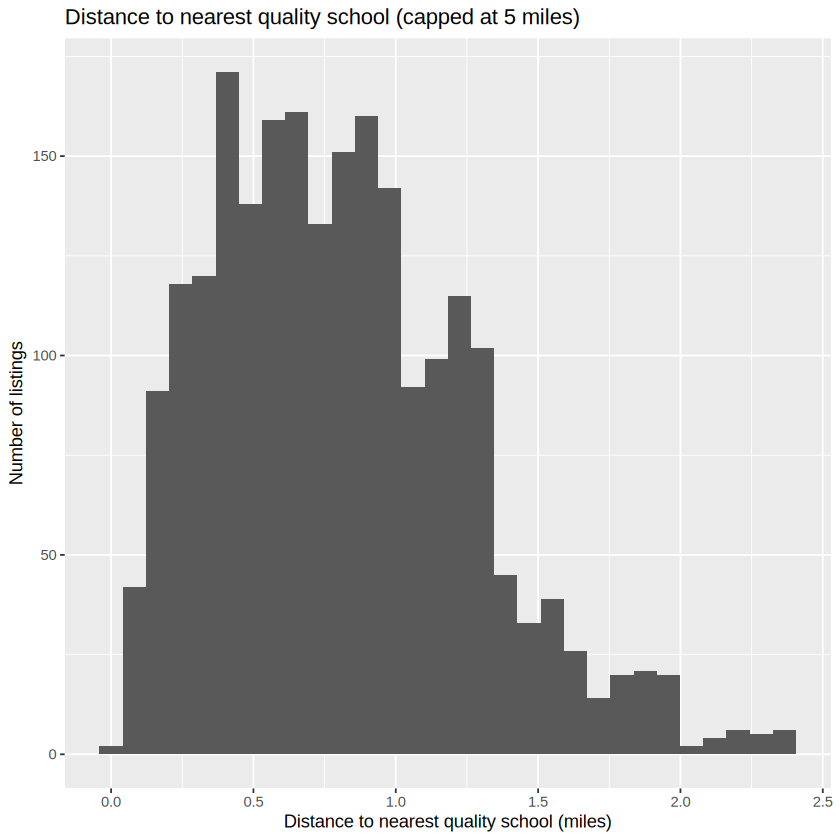

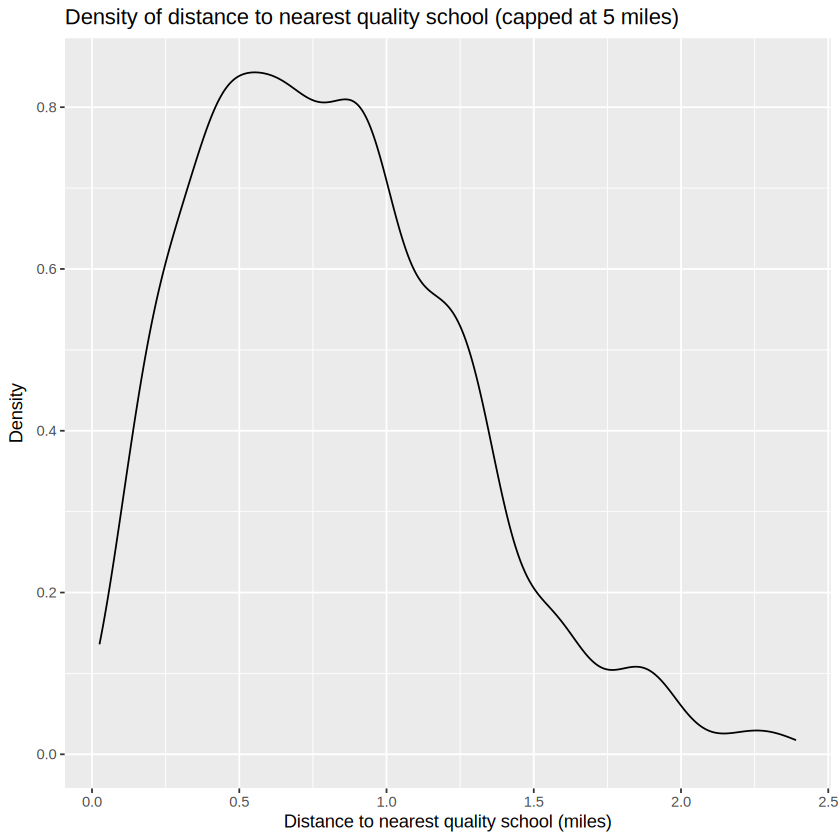

In [31]:
library(dplyr)
library(ggplot2)

# Filter out NAs, and maybe cap at, say, 5 miles to avoid extreme tails
dist_data <- homes_df %>%
  filter(!is.na(distance_to_quality_school_miles)) %>%
  mutate(
    distance_capped = pmin(distance_to_quality_school_miles, 5)
  )

# 1) Histogram
ggplot(dist_data, aes(x = distance_capped)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distance to nearest quality school (capped at 5 miles)",
    x = "Distance to nearest quality school (miles)",
    y = "Number of listings"
  )

# 2) Density plot
ggplot(dist_data, aes(x = distance_capped)) +
  geom_density() +
  labs(
    title = "Density of distance to nearest quality school (capped at 5 miles)",
    x = "Distance to nearest quality school (miles)",
    y = "Density"
  )


In [32]:
library(dplyr)
library(readr)

homes_df <- homes_df %>%
  mutate(
    price_num = readr::parse_number(as.character(PRICE))
  )

# Quick check
summary(homes_df$price_num)



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1000  620000  901000 1167915 1405000 8500000 

In [33]:
homes_df %>%
  summarise(
    n_homes                  = n(),
    median_price_all         = median(price_num, na.rm = TRUE),
    median_price_0_5         = median(price_num[within_0_5_mile_quality_school == 1], na.rm = TRUE),
    median_price_not_0_5     = median(price_num[within_0_5_mile_quality_school == 0], na.rm = TRUE),
    median_price_1_mile      = median(price_num[within_1_mile_quality_school == 1], na.rm = TRUE),
    median_price_not_1_mile  = median(price_num[within_1_mile_quality_school == 0], na.rm = TRUE)
  )


n_homes,median_price_all,median_price_0_5,median_price_not_0_5,median_price_1_mile,median_price_not_1_mile
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2237,901000,1105000,850000,969500,820000


In [34]:
library(dplyr)

homes_df_dist <- homes_df %>%
  filter(!is.na(distance_to_quality_school_miles), !is.na(price_num)) %>%
  mutate(
    dist_band = cut(
      distance_to_quality_school_miles,
      breaks = c(0, 0.25, 0.5, 1, 2, Inf),
      labels = c("0–0.25 mi", "0.25–0.5 mi", "0.5–1 mi", "1–2 mi", "2+ mi"),
      right = TRUE
    )
  )


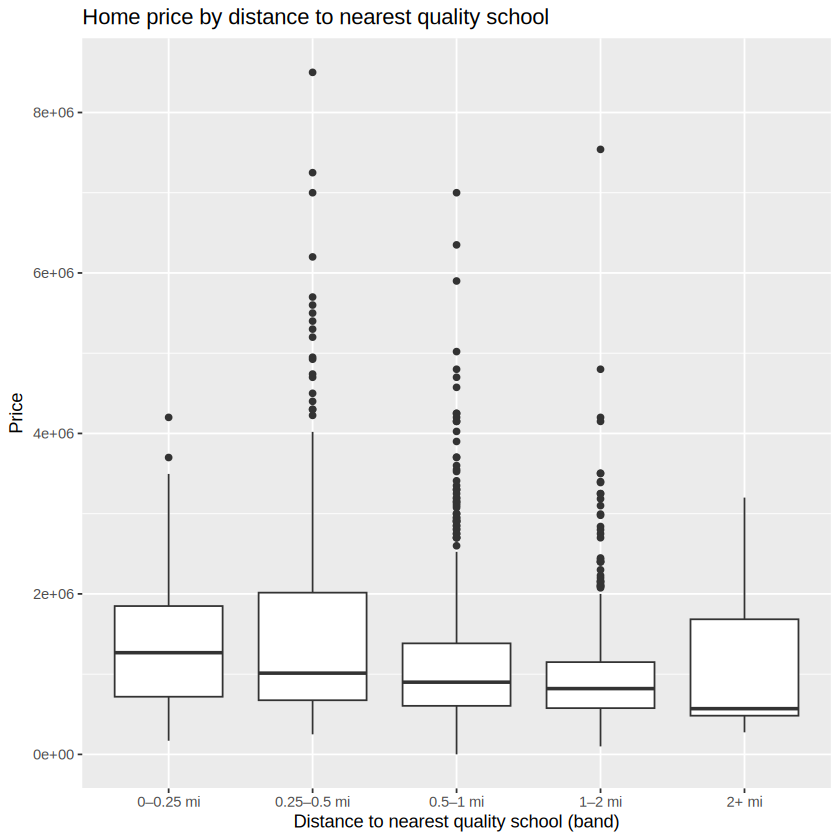

In [35]:
library(ggplot2)

ggplot(homes_df_dist, aes(x = dist_band, y = price_num)) +
  geom_boxplot() +
  labs(
    title = "Home price by distance to nearest quality school",
    x = "Distance to nearest quality school (band)",
    y = "Price"
  )


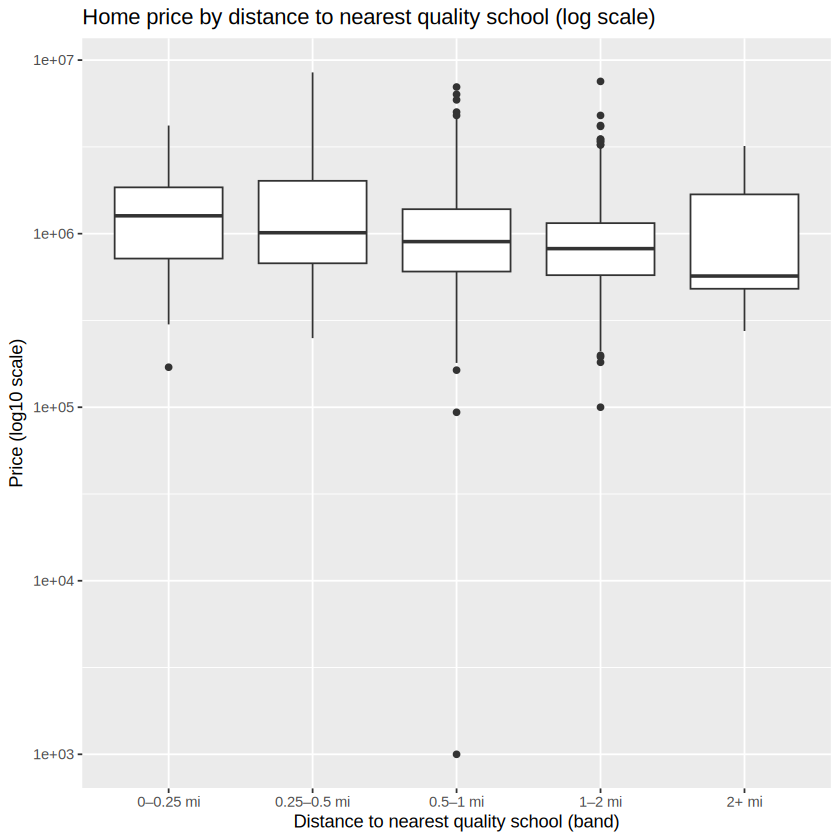

In [36]:
ggplot(homes_df_dist, aes(x = dist_band, y = price_num)) +
  geom_boxplot() +
  scale_y_log10() +
  labs(
    title = "Home price by distance to nearest quality school (log scale)",
    x = "Distance to nearest quality school (band)",
    y = "Price (log10 scale)"
  )


In [37]:
band_summary <- homes_df_dist %>%
  group_by(dist_band) %>%
  summarise(
    n            = n(),
    median_price = median(price_num, na.rm = TRUE),
    mean_price   = mean(price_num, na.rm = TRUE),
    .groups = "drop"
  )

band_summary


dist_band,n,median_price,mean_price
<fct>,<int>,<dbl>,<dbl>
0–0.25 mi,206,1267500,1383351.7
0.25–0.5 mi,418,1012500,1496732.9
0.5–1 mi,932,900000,1117574.3
1–2 mi,658,820000,967518.1
2+ mi,23,570000,1035452.2


dist_band,n,median_price,median_price_k
<fct>,<int>,<dbl>,<dbl>
0–0.25 mi,206,1267500,1267.5
0.25–0.5 mi,418,1012500,1012.5
0.5–1 mi,932,900000,900.0
1–2 mi,658,820000,820.0
2+ mi,23,570000,570.0


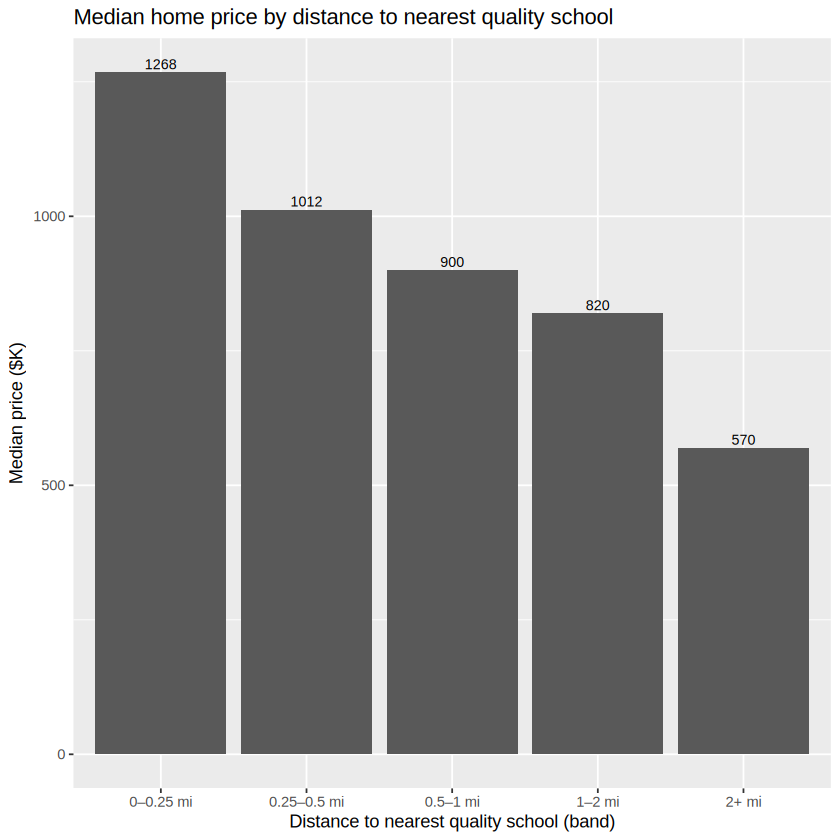

In [38]:
library(dplyr)
library(ggplot2)

# If you already have homes_df_dist from before, you can skip this block
homes_df_dist <- homes_df %>%
  filter(!is.na(distance_to_quality_school_miles), !is.na(price_num)) %>%
  mutate(
    dist_band = cut(
      distance_to_quality_school_miles,
      breaks = c(0, 0.25, 0.5, 1, 2, Inf),
      labels = c("0–0.25 mi", "0.25–0.5 mi", "0.5–1 mi", "1–2 mi", "2+ mi"),
      right = TRUE
    )
  )

band_summary <- homes_df_dist %>%
  group_by(dist_band) %>%
  summarise(
    n            = n(),
    median_price = median(price_num, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    median_price_k = median_price / 1000   # in thousands
  )

band_summary

ggplot(band_summary, aes(x = dist_band, y = median_price_k)) +
  geom_col() +
  geom_text(
    aes(label = round(median_price_k)),
    vjust = -0.3,
    size = 3
  ) +
  labs(
    title = "Median home price by distance to nearest quality school",
    x = "Distance to nearest quality school (band)",
    y = "Median price ($K)"
  )


# Amenities proximity calc



In [39]:
library(tidyverse)

amenities <- tribble(
  ~name,                                   ~category,              ~address,
  # Groceries
  "Whole Foods - Telegraph",               "grocery",              "5110 Telegraph Ave, Oakland, CA 94609",
  "Whole Foods - Lake Merritt",            "grocery",              "230 Bay Pl, Oakland, CA 94612",
  "Trader Joe's - Lakeshore",              "grocery",              "3250 Lakeshore Ave, Oakland, CA 94610",
  "Trader Joe's - Rockridge",              "grocery",              "5727 College Ave, Oakland, CA 94618",
  "Costco - Richmond",                     "grocery",              "4801 Central Ave, Richmond, CA 94804",
  "Costco - San Leandro",                  "grocery",              "1900 Davis St, San Leandro, CA 94577",

  # Major retail/dining clusters
  "Montclair Village",                     "retail_dining",        "1963 Mountain Blvd, Oakland, CA 94611",
  "Rockridge Commercial Strip",            "retail_dining",        "College Ave & Claremont Ave, Oakland, CA 94618",
  "Temescal District",                     "retail_dining",        "4701 Telegraph Ave, Oakland, CA",
  "Grand Ave / Grand Lake District",       "retail_dining",        "3200 Grand Ave, Oakland, CA 94610",
  "Lakeshore District",                    "retail_dining",        "3300 Lakeshore Ave, Oakland, CA 94610",

  # Shopping centers
  "Bayfair Center",                        "shopping_center",      "15555 E 14th St, San Leandro, CA 94578",
  "Bay Street Emeryville",                 "shopping_center",      "5614 Bay St, Emeryville, CA 94608",
  "Target - Alameda",                      "shopping_center",      "2700 5th St, Alameda, CA 94501",

  # Hiking / Oakland hills
  "Redwood Regional - Skyline Gate",       "hiking",               "8490 Skyline Blvd, Oakland, CA 94611",
  "Joaquin Miller Park",                   "hiking",               "3450 Joaquin Miller Rd, Oakland, CA 94602",

  # Waterfronts
  "Jack London Square Waterfront",         "waterfront",           "98 Broadway, Oakland, CA 94607",

  # Employers — CLEAN OFFICE
  "Pixar Animation Studios",               "employer_pixar",       "1200 Park Ave, Emeryville, CA 94608",
  "PG&E HQ",                               "employer_downtown",       "300 Lakeside Dr, Oakland, CA 94612",
  "University of California, Berkeley",    "employer_college",       "2512A Telegraph Ave, Berkeley, CA 94704",
  "TPMG",                                  "employer_downtown",       "1950 Franklin Street, Oakland, CA 94612",

  # Employers — INDUSTRIAL / LOGISTICS / MANUFACTURING
  "Port of Oakland - Seaport",             "employer_industrial",  "530 Water St, Oakland, CA 94607",
  "Oakland Int'l Airport & Cargo (OAK)",   "employer_industrial",  "1 Airport Dr, Oakland, CA 94621",
  "Oakland Global Trade & Logistics Hub",  "employer_industrial",  "2400 W 7th St, Oakland, CA 94607",
  "Tesla Fremont Factory",                 "employer_industrial",  "45500 Fremont Blvd, Fremont, CA 94538"
    

)


In [40]:
install.packages("tidygeocoder")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [41]:
library(tidygeocoder)

amenities_geo <- amenities %>%
  geocode(address, method = "osm", lat = latitude, long = longitude)

amenities_geo


Warning message:
“package ‘tidygeocoder’ was built under R version 4.5.2”
Passing 25 addresses to the Nominatim single address geocoder

Query completed in: 66.4 seconds



name,category,address,latitude,longitude
<chr>,<chr>,<chr>,<dbl>,<dbl>
Whole Foods - Telegraph,grocery,"5110 Telegraph Ave, Oakland, CA 94609",37.83752,-122.2616
Whole Foods - Lake Merritt,grocery,"230 Bay Pl, Oakland, CA 94612",37.81309,-122.2607
Trader Joe's - Lakeshore,grocery,"3250 Lakeshore Ave, Oakland, CA 94610",37.80979,-122.2443
Trader Joe's - Rockridge,grocery,"5727 College Ave, Oakland, CA 94618",37.84554,-122.2526
Costco - Richmond,grocery,"4801 Central Ave, Richmond, CA 94804",37.89884,-122.3202
Costco - San Leandro,grocery,"1900 Davis St, San Leandro, CA 94577",37.72081,-122.1819
Montclair Village,retail_dining,"1963 Mountain Blvd, Oakland, CA 94611",37.82801,-122.2105
Rockridge Commercial Strip,retail_dining,"College Ave & Claremont Ave, Oakland, CA 94618",37.84877,-122.2523
Temescal District,retail_dining,"4701 Telegraph Ave, Oakland, CA",37.83448,-122.2633


In [42]:
library(sf)
library(dplyr)
library(purrr)

# 1) Convert homes_df to sf
homes_sf <- homes_df %>%
  st_as_sf(coords = c("LONGITUDE", "LATITUDE"), crs = 4326, remove = FALSE)

# 2) Convert amenities to sf
amenities_sf <- amenities_geo %>%
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326, remove = FALSE)

# Helper: compute minimum distance (in miles) from each home to any amenity in a category
dist_to_category <- function(category_name) {
  cat_points <- amenities_sf %>% filter(category == category_name)

  # st_distance returns a matrix of distances in meters
  dmat <- st_distance(homes_sf, cat_points)  # homes x amenities

  # Take min distance per home, convert meters to miles
  min_meters <- apply(dmat, 1, min)
  min_miles  <- as.numeric(min_meters) / 1609.34

  tibble(!!paste0("dist_to_", category_name, "_miles") := min_miles)
}

# List of categories to create columns for
cats <- c("grocery", "retail_dining", "shopping_center", "hiking", "waterfront", "employer_pixar", "employer_industrial", "employer_downtown", "employer_college")

# 3) Build a tibble of all distance columns
dist_cols <- map_dfc(cats, dist_to_category)

# 4) Remove any existing distance-to-amenity columns before adding new ones
homes_df_clean <- homes_df %>%
  select(
    -starts_with("dist_to_grocery_miles"),
    -starts_with("dist_to_retail_dining_miles"),
    -starts_with("dist_to_shopping_center_miles"),
    -starts_with("dist_to_hiking_miles"),
    -starts_with("dist_to_waterfront_miles"),
    -starts_with("dist_to_employer_clean_miles"),
    -starts_with("dist_to_employer_industrial_miles")
  )

# 5) Bind newly-created distance columns safely
homes_df_with_amenities <- bind_cols(homes_df_clean, dist_cols)



In [43]:
homes_df <- homes_df_with_amenities
colnames(homes_df)


[1] "SALE TYPE"                                                                                  
 [2] "SOLD DATE"                                                                                  
 [3] "PROPERTY TYPE"                                                                              
 [4] "ADDRESS"                                                                                    
 [5] "CITY"                                                                                       
 [6] "STATE OR PROVINCE"                                                                          
 [7] "ZIP OR POSTAL CODE"                                                                         
 [8] "PRICE"                                                                                      
 [9] "BEDS"                                                                                       
[10] "BATHS"                                                                                      
[11] "LOCATION"                                                                                   
[12] "SQUARE FEET"                                                                                
[13] "LOT SIZE"                                                                                   
[14] "YEAR BUILT"                                                                                 
[15] "DAYS ON MARKET"                                                                             
[16] "$/SQUARE FEET"                                                                              
[17] "HOA/MONTH"                                                                                  
[18] "STATUS"                                                                                     
[19] "NEXT OPEN HOUSE START TIME"                                                                 
[20] "NEXT OPEN HOUSE END TIME"                                                                   
[21] "URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING)"
[22] "SOURCE"                                                                                     
[23] "MLS#"                                                                                       
[24] "FAVORITE"                                                                                   
[25] "INTERESTED"                                                                                 
[26] "LATITUDE"                                                                                   
[27] "LONGITUDE"                                                                                  
[28] "distance_to_bart_miles"                                                                     
[29] "within_0_5_miles_bart"                                                                      
[30] "distance_to_quality_school_miles"                                                           
[31] "nearest_quality_school_name"                                                                
[32] "nearest_quality_school_quality_distance"                                                    
[33] "nearest_quality_school_quality_level"                                                       
[34] "within_2_miles_quality_school"                                                              
[35] "within_0_5_mile_quality_school"                                                             
[36] "within_1_mile_quality_school"                                                               
[37] "price_num"                                                                                  
[38] "dist_to_grocery_miles"                                                                      
[39] "dist_to_retail_dining_miles"                                                                
[40] "dist_to_shopping_center_miles"                                                              
[41] "dist_to_hiking_miles"              

In [44]:
set.seed(123)  # for reproducibility, optional

homes_df %>%
  dplyr::slice_sample(n = 10) %>%              # grab 10 random listings
  dplyr::select(
    ADDRESS, CITY, PRICE,                      # core listing info (adjust to your cols)
    LATITUDE, LONGITUDE,
    dplyr::starts_with("dist_to_")            # all the new amenity distance columns
  )


ADDRESS,CITY,PRICE,LATITUDE,LONGITUDE,dist_to_grocery_miles,dist_to_retail_dining_miles,dist_to_shopping_center_miles,dist_to_hiking_miles,dist_to_waterfront_miles,dist_to_employer_pixar_miles,dist_to_employer_industrial_miles,dist_to_employer_downtown_miles,dist_to_employer_college_miles
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
402 Hiller Dr,Oakland,925000,37.85368,-122.2262,1.5454525,1.4628948,3.842013,0.6494815,4.897004,3.4552701,4.9248384,3.7262586,2.114833
1116 16th St,Oakland,876000,37.81114,-122.2850,1.3342641,2.0011588,1.549991,4.8360853,1.223272,1.4891921,0.6830598,1.0337291,4.268819
2033 Harrington Ave,Oakland,195000,37.78199,-122.2155,2.4810784,2.5102953,3.592797,2.4857342,3.435385,5.1108052,3.5861265,3.2331619,6.504602
6258 Boulder Ln #4801,Oakland,795000,37.77953,-122.1646,4.1660273,4.1855013,5.846700,2.3821367,6.190523,7.4679105,4.8174156,5.7953815,8.089534
1009 Winsor Ave,Piedmont,2100000,37.81640,-122.2373,0.5950197,0.5484011,3.034921,2.8310480,2.598023,2.7718602,2.6793241,1.5538472,3.863492
4614 Rockingham Ct,Oakland,4800000,37.78582,-122.1643,4.5929097,3.8561336,6.249684,2.0245945,6.145203,7.2768482,5.2120908,5.6721495,7.770205
868 44th St,Emeryville,1175000,37.83381,-122.2722,0.6339907,0.4862456,1.072749,3.4334778,2.701295,0.6323802,2.3474068,1.7859899,2.563626
9057 Skyline Blvd,Oakland,2400000,37.82622,-122.1891,3.2174252,1.1764824,5.623285,1.1667697,5.228566,5.1811715,5.3304069,4.2645979,4.863836
6907 Chambers Dr,Oakland,965000,37.83621,-122.1990,2.9936298,0.8455159,5.068166,1.4480853,5.092782,4.6261225,5.1743860,4.0227361,4.017701


# HOLC Zone Calc


In [45]:
library(sf)
library(dplyr)

# --- 0. Make sure both layers use the same CRS (WGS84 / 4326) ---

# If oakland_sf_valid is already 4326, this is a no-op but safe:
oakland_sf_valid <- st_transform(oakland_sf_valid, 4326)

# Homes as sf points (you already used this pattern before)
homes_sf <- homes_df %>%
  st_as_sf(coords = c("LONGITUDE", "LATITUDE"),
           crs = 4326,
           remove = FALSE)

# --- 1. Keep only the HOLC grade from the polygons ---

oakland_zones <- oakland_sf_valid %>%
  select(grade)  # 'grade' is the A/B/C/D column

# --- 2. Spatial join: assign each listing the HOLC grade of the polygon it falls in ---

homes_with_holc_sf <- st_join(
  homes_sf,
  oakland_zones,
  join = st_within,  # point-in-polygon
  left = TRUE        # keep all homes; grade will be NA if outside any zone
)

# --- 3. Map grade -> color and drop geometry back to a regular data frame ---

holc_colors <- c("A" = "green", "B" = "blue", "C" = "yellow", "D" = "red")

homes_df <- homes_with_holc_sf %>%
  st_drop_geometry() %>%
  mutate(
    holc_grade = grade,  # rename for clarity
    holc_grade = factor(holc_grade, levels = c("A", "B", "C", "D")),
    holc_color = holc_colors[as.character(holc_grade)]
  )


In [46]:
# How many listings in each HOLC grade?
homes_df %>% count(holc_grade)

# Peek at random listings with their HOLC tag + distances
set.seed(123)
homes_df %>%
  slice_sample(n = 5) %>%
  select(ADDRESS, CITY, holc_grade, holc_color, starts_with("dist_to_"))


holc_grade,n
<fct>,<int>
A,275
B,452
C,669
D,402
NA,439


ADDRESS,CITY,holc_grade,holc_color,dist_to_grocery_miles,dist_to_retail_dining_miles,dist_to_shopping_center_miles,dist_to_hiking_miles,dist_to_waterfront_miles,dist_to_employer_pixar_miles,dist_to_employer_industrial_miles,dist_to_employer_downtown_miles,dist_to_employer_college_miles
<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
402 Hiller Dr,Oakland,NA,NA,1.5454525,1.4628948,3.842013,0.6494815,4.897004,3.455270,4.9248384,3.726259,2.114833
1116 16th St,Oakland,D,red,1.3342641,2.0011588,1.549991,4.8360853,1.223272,1.489192,0.6830598,1.033729,4.268819
2033 Harrington Ave,Oakland,C,yellow,2.4810784,2.5102953,3.592797,2.4857342,3.435385,5.110805,3.5861265,3.233162,6.504602
6258 Boulder Ln #4801,Oakland,NA,NA,4.1660273,4.1855013,5.846700,2.3821367,6.190523,7.467911,4.8174156,5.795381,8.089534
1009 Winsor Ave,Piedmont,B,blue,0.5950197,0.5484011,3.034921,2.8310480,2.598023,2.771860,2.6793241,1.553847,3.863492


In [47]:
library(dplyr)

homes_df <- homes_df %>%
  mutate(
    # Grade-based dummies
    is_HOLC_A = if_else(holc_grade == "A", 1L, 0L, missing = 0L),
    is_HOLC_B = if_else(holc_grade == "B", 1L, 0L, missing = 0L),
    is_HOLC_C = if_else(holc_grade == "C", 1L, 0L, missing = 0L),
    is_HOLC_D = if_else(holc_grade == "D", 1L, 0L, missing = 0L),

    # Color-based dummy for “redlined” (HOLC D)
    is_HOLC_red = if_else(holc_color == "red", 1L, 0L, missing = 0L)
  )


In [48]:
homes_df %>%
  count(holc_grade, is_HOLC_red)


holc_grade,is_HOLC_red,n
<fct>,<int>,<int>
A,0,275
B,0,452
C,0,669
D,1,402
NA,0,439


# Sold Year Fixed Effect


In [49]:
library(dplyr)
library(lubridate)

homes_df <- homes_df %>%
  mutate(
    sale_date = mdy(`SOLD DATE`),      # parse "SOLD DATE" column
    sale_year = year(sale_date)        # extract year
  )


In [50]:
homes_df <- homes_df %>%
  mutate(
    sale_year = factor(sale_year)
  )


In [51]:
table(homes_df$sale_year)



2020 2021 2022 2023 2024 2025 
  89  636  400  265  256  240 

In [52]:
library(dplyr)

homes_df <- homes_df %>%
  mutate(
    # 1) Clean year built into numeric
    year_built = as.numeric(`YEAR BUILT`),

    # 2) Make sure sale_year is numeric (not factor) for the calc
    sale_year_num = as.numeric(as.character(sale_year)),

    # 3) Age of house at time of sale
    age_at_sale = sale_year_num - year_built
  )


In [53]:
homes_df %>%
  select(`YEAR BUILT`, year_built, sale_year, sale_year_num, age_at_sale) %>%
  head()


YEAR BUILT,year_built,sale_year,sale_year_num,age_at_sale
<dbl>,<dbl>,<fct>,<dbl>,<dbl>
1928,1928,2023,2023,95
1955,1955,2022,2022,67
1925,1925,NA,NA,NA
1996,1996,NA,NA,NA
1928,1928,NA,NA,NA
1951,1951,2022,2022,71


# LASSO

In [54]:
library(dplyr)
library(purrr)

# Quick glance
glimpse(homes_df)


Rows: 2,237
Columns: 59
$ `SALE TYPE`                                                                                   <chr> …
$ `SOLD DATE`                                                                                   <chr> …
$ `PROPERTY TYPE`                                                                               <chr> …
$ ADDRESS                                                                                       <chr> …
$ CITY                                                                                          <chr> …
$ `STATE OR PROVINCE`                                                                           <chr> …
$ `ZIP OR POSTAL CODE`                                                                          <dbl> …
$ PRICE                                                                                         <dbl> …
$ BEDS                                                                                          <dbl> …
$ BATHS                                 

In [55]:
library(dplyr)
library(glmnet)

model_df <- homes_df %>%
  select(
    PRICE,
    BEDS,
    BATHS,
    `SQUARE FEET`,
    age_at_sale,
    distance_to_bart_miles,
    within_0_5_miles_bart,
    distance_to_quality_school_miles,
    within_0_5_mile_quality_school,
    dist_to_grocery_miles,
    dist_to_retail_dining_miles,
    dist_to_shopping_center_miles,
    dist_to_hiking_miles,
    dist_to_waterfront_miles,
    dist_to_employer_industrial_miles,
    is_HOLC_A,
    is_HOLC_B,
    is_HOLC_D,
    sale_year
    # (note: not including is_HOLC_red to avoid redundancy with is_HOLC_D)
  ) %>%
  tidyr::drop_na() %>%          # drop rows with any missing values in these cols
  mutate(
    log_price = log(PRICE),
    sale_year = factor(sale_year)   # make sure year is a factor for FE
  )


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10



In [56]:
# Model matrix: glmnet wants a numeric matrix for X
x <- model.matrix(
  log_price ~
    BEDS +
    BATHS + 
    `SQUARE FEET` +
    age_at_sale +
    within_0_5_miles_bart +
    distance_to_quality_school_miles + 
    within_0_5_mile_quality_school +
    dist_to_grocery_miles +
    dist_to_retail_dining_miles +
    dist_to_shopping_center_miles +
    dist_to_waterfront_miles + 
    dist_to_employer_industrial_miles +
    is_HOLC_A + is_HOLC_B + is_HOLC_D +
    sale_year,     # year fixed effects via dummies
  data = model_df
)

# Drop intercept column (first col)
x <- x[, -1]

# Outcome
y <- model_df$log_price


In [57]:
set.seed(123)

lasso_cv <- cv.glmnet(
  x, y,
  alpha = 1,         # LASSO
  nfolds = 10        # CV folds
)

# Best lambda (min CV error)
lasso_cv$lambda.min

# Slightly more regularized (1-SE rule)
lasso_cv$lambda.1se


[1] 0.0004395866

[1] 0.07332746

In [58]:
coef_min <- coef(lasso_cv, s = "lambda.min")
coef_min


21 x 1 sparse Matrix of class "dgCMatrix"
                                     lambda.min
(Intercept)                       12.8186717650
BEDS                               0.0331825834
BATHS                              0.0628556399
`SQUARE FEET`                      0.0002949457
age_at_sale                        0.0005347498
within_0_5_miles_bart              0.0494358395
distance_to_quality_school_miles   0.0418187269
within_0_5_mile_quality_school     0.1065252785
dist_to_grocery_miles             -0.0427898875
dist_to_retail_dining_miles       -0.0495848502
dist_to_shopping_center_miles     -0.0696538717
dist_to_waterfront_miles           0.0029168625
dist_to_employer_industrial_miles  0.1369337531
is_HOLC_A                          0.1085917702
is_HOLC_B                          0.1457679204
is_HOLC_D                         -0.0691852448
sale_year2021                      0.0812467510
sale_year2022                      0.0948699170
sale_year2023                      0.037178861

In [59]:
library(tibble)

coef_tbl <- coef_min %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# Non-zero coefficients only
coef_tbl %>%
  filter(coefficient != 0)


variable,coefficient
<chr>,<dbl>
(Intercept),12.8186717650
BEDS,0.0331825834
BATHS,0.0628556399
`SQUARE FEET`,0.0002949457
age_at_sale,0.0005347498
within_0_5_miles_bart,0.0494358395
distance_to_quality_school_miles,0.0418187269
within_0_5_mile_quality_school,0.1065252785
dist_to_grocery_miles,-0.0427898875


In [60]:
library(tibble)
library(dplyr)

# Coefficients at lambda.min
coef_min <- coef(lasso_cv, s = "lambda.min")

coef_tbl <- coef_min %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# Separate intercept
intercept <- coef_tbl %>%
  filter(variable == "(Intercept)")

# Variables kept (non-zero, excluding intercept)
vars_kept <- coef_tbl %>%
  filter(variable != "(Intercept)",
         coefficient != 0)

# Variables removed (exactly zero)
vars_removed <- coef_tbl %>%
  filter(variable != "(Intercept)",
         coefficient == 0)

# View them
vars_kept
vars_removed
intercept


variable,coefficient
<chr>,<dbl>
BEDS,0.0331825834
BATHS,0.0628556399
`SQUARE FEET`,0.0002949457
age_at_sale,0.0005347498
within_0_5_miles_bart,0.0494358395
distance_to_quality_school_miles,0.0418187269
within_0_5_mile_quality_school,0.1065252785
dist_to_grocery_miles,-0.0427898875
dist_to_retail_dining_miles,-0.0495848502


variable,coefficient
<chr>,<dbl>


variable,coefficient
<chr>,<dbl>
(Intercept),12.81867


In [61]:
library(dplyr)
library(tibble)
library(stringr)

# Coefficients from LASSO at lambda.min
coef_min <- coef(lasso_cv, s = "lambda.min")

coef_tbl <- coef_min %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# Remove intercept, add absolute value, sort by |coef|
coef_sorted <- coef_tbl %>%
  filter(variable != "(Intercept)") %>%
  mutate(abs_coef = abs(coefficient)) %>%
  arrange(desc(abs_coef))

# Look at the top 10 to sanity check
coef_sorted %>% head(22)


variable,coefficient,abs_coef
<chr>,<dbl>,<dbl>
is_HOLC_B,0.1457679204,0.1457679204
dist_to_employer_industrial_miles,0.1369337531,0.1369337531
is_HOLC_A,0.1085917702,0.1085917702
within_0_5_mile_quality_school,0.1065252785,0.1065252785
sale_year2022,0.0948699170,0.0948699170
sale_year2021,0.0812467510,0.0812467510
dist_to_shopping_center_miles,-0.0696538717,0.0696538717
is_HOLC_D,-0.0691852448,0.0691852448
BATHS,0.0628556399,0.0628556399


In [62]:
model_ols <- lm(
  log(PRICE) ~ BATHS + BEDS + is_HOLC_A + is_HOLC_B + is_HOLC_D + `SQUARE FEET` +
    sale_year,
  data = homes_df
)

summary(model_ols)



Call:
lm(formula = log(PRICE) ~ BATHS + BEDS + is_HOLC_A + is_HOLC_B + 
    is_HOLC_D + `SQUARE FEET` + sale_year, data = homes_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.4577 -0.2057  0.0028  0.2278  1.0222 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    1.289e+01  4.447e-02 289.774  < 2e-16 ***
BATHS          6.948e-02  1.470e-02   4.727 2.45e-06 ***
BEDS           2.085e-02  1.017e-02   2.049   0.0406 *  
is_HOLC_A      2.811e-01  2.850e-02   9.861  < 2e-16 ***
is_HOLC_B      2.260e-01  2.251e-02  10.038  < 2e-16 ***
is_HOLC_D     -1.136e-01  2.364e-02  -4.807 1.66e-06 ***
`SQUARE FEET`  3.300e-04  1.727e-05  19.110  < 2e-16 ***
sale_year2021  7.528e-02  4.153e-02   1.813   0.0700 .  
sale_year2022  9.144e-02  4.298e-02   2.128   0.0335 *  
sale_year2023  3.577e-02  4.496e-02   0.796   0.4264    
sale_year2024  3.369e-02  4.518e-02   0.746   0.4559    
sale_year2025 -3.943e-02  4.552e-02  -0.866   0.3865    
---
Signif. codes

# Takeaway Look for D-level / historically redlined areas that have a Pixar-level employer, waterfront/downtown proximity, and active infill development — places where the “big forces” are strong enough to bend the usual D discount at the zip level

94607 and 94608 both have a pretty high share of HOLC D,

but their price difference vs 94609 is basically ~0% (or even slightly positive for 94608),

whereas other high-D zips (94601, 94603, 94621) are −30–45% cheaper.

So the story is roughly:

94607 = West Oakland / Jack London

Lots of historically D-graded areas.

But also super strong location advantages: right next to downtown, BART, the waterfront, new lofts/condos, SF access, etc.

Those forces have pushed prices up enough to offset the D penalty at the zip level.

94608 = North Oakland / Emeryville

Historically redlined pockets, but: Pixar, Bay Street, tons of new development, very SF-adjacent.

Again, big gentrification + job center + retail story that counteracts the “redlined zip = cheap” pattern.

In [63]:
library(tidyverse)

# See structure + column types
glimpse(homes_df)

# See the column names explicitly
colnames(homes_df)

# Random sample of 15 *full* rows (all columns)
set.seed(123)  # so you can reproduce the same sample if needed

homes_df %>%
  slice_sample(n = 15)


Rows: 2,237
Columns: 59
$ `SALE TYPE`                                                                                   <chr> …
$ `SOLD DATE`                                                                                   <chr> …
$ `PROPERTY TYPE`                                                                               <chr> …
$ ADDRESS                                                                                       <chr> …
$ CITY                                                                                          <chr> …
$ `STATE OR PROVINCE`                                                                           <chr> …
$ `ZIP OR POSTAL CODE`                                                                          <dbl> …
$ PRICE                                                                                         <dbl> …
$ BEDS                                                                                          <dbl> …
$ BATHS                                 

[1] "SALE TYPE"                                                                                  
 [2] "SOLD DATE"                                                                                  
 [3] "PROPERTY TYPE"                                                                              
 [4] "ADDRESS"                                                                                    
 [5] "CITY"                                                                                       
 [6] "STATE OR PROVINCE"                                                                          
 [7] "ZIP OR POSTAL CODE"                                                                         
 [8] "PRICE"                                                                                      
 [9] "BEDS"                                                                                       
[10] "BATHS"                                                                                      
[11] "LOCATION"                                                                                   
[12] "SQUARE FEET"                                                                                
[13] "LOT SIZE"                                                                                   
[14] "YEAR BUILT"                                                                                 
[15] "DAYS ON MARKET"                                                                             
[16] "$/SQUARE FEET"                                                                              
[17] "HOA/MONTH"                                                                                  
[18] "STATUS"                                                                                     
[19] "NEXT OPEN HOUSE START TIME"                                                                 
[20] "NEXT OPEN HOUSE END TIME"                                                                   
[21] "URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING)"
[22] "SOURCE"                                                                                     
[23] "MLS#"                                                                                       
[24] "FAVORITE"                                                                                   
[25] "INTERESTED"                                                                                 
[26] "LATITUDE"                                                                                   
[27] "LONGITUDE"                                                                                  
[28] "distance_to_bart_miles"                                                                     
[29] "within_0_5_miles_bart"                                                                      
[30] "distance_to_quality_school_miles"                                                           
[31] "nearest_quality_school_name"                                                                
[32] "nearest_quality_school_quality_distance"                                                    
[33] "nearest_quality_school_quality_level"                                                       
[34] "within_2_miles_quality_school"                                                              
[35] "within_0_5_mile_quality_school"                                                             
[36] "within_1_mile_quality_school"                                                               
[37] "price_num"                                                                                  
[38] "dist_to_grocery_miles"                                                                      
[39] "dist_to_retail_dining_miles"                                                                
[40] "dist_to_shopping_center_miles"                                                              
[41] "dist_to_hiking_miles"              

SALE TYPE,SOLD DATE,PROPERTY TYPE,ADDRESS,CITY,STATE OR PROVINCE,ZIP OR POSTAL CODE,PRICE,BEDS,BATHS,⋯,is_HOLC_A,is_HOLC_B,is_HOLC_C,is_HOLC_D,is_HOLC_red,sale_date,sale_year,year_built,sale_year_num,age_at_sale
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<date>,<fct>,<dbl>,<dbl>,<dbl>
PAST SALE,August-26-2025,Townhouse,402 Hiller Dr,Oakland,CA,94618,925000,3,2.5,⋯,0,0,0,0,0,2025-08-26,2025,1994,2025,31
PAST SALE,September-3-2024,Single Family Residential,1116 16th St,Oakland,CA,94607,876000,3,2.0,⋯,0,0,0,1,1,2024-09-03,2024,1980,2024,44
PAST SALE,NA,Single Family Residential,2033 Harrington Ave,Oakland,CA,94601,195000,2,1.0,⋯,0,0,1,0,0,NA,NA,1922,NA,NA
PAST SALE,August-20-2021,Condo/Co-op,6258 Boulder Ln #4801,Oakland,CA,94605,795000,3,2.5,⋯,0,0,0,0,0,2021-08-20,2021,2010,2021,11
PAST SALE,November-10-2022,Single Family Residential,1009 Winsor Ave,Piedmont,CA,94610,2100000,4,2.5,⋯,0,1,0,0,0,2022-11-10,2022,1919,2022,103
PAST SALE,October-18-2021,Single Family Residential,4614 Rockingham Ct,Oakland,CA,94619,4800000,7,8.5,⋯,0,0,0,0,0,2021-10-18,2021,2005,2021,16
PAST SALE,September-13-2024,Single Family Residential,868 44th St,Emeryville,CA,94608,1175000,5,3.5,⋯,0,0,0,1,1,2024-09-13,2024,1914,2024,110
PAST SALE,July-9-2021,Single Family Residential,9057 Skyline Blvd,Oakland,CA,94611,2400000,4,3.0,⋯,1,0,0,0,0,2021-07-09,2021,1950,2021,71
PAST SALE,May-11-2023,Single Family Residential,6907 Chambers Dr,Oakland,CA,94611,965000,3,2.0,⋯,1,0,0,0,0,2023-05-11,2023,1955,2023,68


In [64]:
set.seed(123)  # so your sample is reproducible

homes_df %>%
  slice_sample(n = 15) %>%
  select(
    distance_to_bart_miles,
    within_0_5_miles_bart,
    distance_to_quality_school_miles,
    nearest_quality_school_name,
    nearest_quality_school_quality_distance,
    nearest_quality_school_quality_level,
    within_2_miles_quality_school,
    within_0_5_mile_quality_school,
    within_1_mile_quality_school,
    price_num,
    dist_to_grocery_miles,
    dist_to_retail_dining_miles,
    dist_to_shopping_center_miles,
    dist_to_hiking_miles,
    dist_to_waterfront_miles,
    dist_to_employer_industrial_miles
  )


distance_to_bart_miles,within_0_5_miles_bart,distance_to_quality_school_miles,nearest_quality_school_name,nearest_quality_school_quality_distance,nearest_quality_school_quality_level,within_2_miles_quality_school,within_0_5_mile_quality_school,within_1_mile_quality_school,price_num,dist_to_grocery_miles,dist_to_retail_dining_miles,dist_to_shopping_center_miles,dist_to_hiking_miles,dist_to_waterfront_miles,dist_to_employer_industrial_miles
<dbl>,<int>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.5016933,0,0.9348404,Chabot Elementary,40.90,4,1,0,1,925000,1.5454525,1.4628948,3.842013,0.6494815,4.897004,4.9248384
0.7016178,0,0.5112752,Yu Ming Charter,91.65,5,1,0,1,876000,1.3342641,2.0011588,1.549991,4.8360853,1.223272,0.6830598
0.6822649,0,1.3634555,Downtown Charter Academy,51.05,5,1,0,0,195000,2.4810784,2.5102953,3.592797,2.4857342,3.435385,3.5861265
2.5097184,0,1.2108160,Oakland Unity High,0.70,4,1,0,0,795000,4.1660273,4.1855013,5.846700,2.3821367,6.190523,4.8174156
1.7980513,0,0.6422999,Crocker Highlands Elementary,48.25,5,1,0,1,2100000,0.5950197,0.5484011,3.034921,2.8310480,2.598023,2.6793241
2.8439703,0,1.4272076,Oakland Unity High,0.70,4,1,0,0,4800000,4.5929097,3.8561336,6.249684,2.0245945,6.145203,5.2120908
0.4304829,1,1.2106267,Yu Ming Charter,91.65,5,1,0,0,1175000,0.6339907,0.4862456,1.072749,3.4334778,2.701295,2.3474068
3.6191285,0,0.8712733,Joaquin Miller Elementary,2.50,4,1,0,1,2400000,3.2174252,1.1764824,5.623285,1.1667697,5.228566,5.3304069
2.9128161,0,0.6811770,Thornhill Elementary,36.70,4,1,0,1,965000,2.9936298,0.8455159,5.068166,1.4480853,5.092782,5.1743860


In [65]:
library(dplyr)
library(readr)

homes_extended_df <- homes_df %>%
  # add a clean zip_code column for modeling (character version of ZIP OR POSTAL CODE)
  mutate(
    zip_code = as.character(`ZIP OR POSTAL CODE`)
  ) %>%
  # keep ONLY the columns you listed, plus zip_code at the end
  select(
    `SALE TYPE`,
    `SOLD DATE`,
    `PROPERTY TYPE`,
    ADDRESS,
    CITY,
    `STATE OR PROVINCE`,
    `ZIP OR POSTAL CODE`,
    PRICE,
    BEDS,
    BATHS,
    LOCATION,
    `SQUARE FEET`,
    `LOT SIZE`,
    `YEAR BUILT`,
    `DAYS ON MARKET`,
    `$/SQUARE FEET`,
    `HOA/MONTH`,
    STATUS,
    `NEXT OPEN HOUSE START TIME`,
    `NEXT OPEN HOUSE END TIME`,
    `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING)`,
    SOURCE,
    `MLS#`,
    FAVORITE,
    INTERESTED,
    LATITUDE,
    LONGITUDE,
    distance_to_bart_miles,
    within_0_5_miles_bart,
    distance_to_quality_school_miles,
    nearest_quality_school_name,
    nearest_quality_school_quality_distance,
    nearest_quality_school_quality_level,
    within_2_miles_quality_school,
    within_0_5_mile_quality_school,
    within_1_mile_quality_school,
    price_num,
    grade,
    holc_grade,
    holc_color,
    is_HOLC_A,
    is_HOLC_B,
    is_HOLC_C,
    is_HOLC_D,
    is_HOLC_red,
    sale_date,
    sale_year,
    year_built,
    sale_year_num,
    age_at_sale,
    dist_to_grocery_miles,
    dist_to_retail_dining_miles,
    dist_to_shopping_center_miles,
    dist_to_hiking_miles,
    dist_to_waterfront_miles,
    dist_to_employer_industrial_miles,
    dist_to_employer_pixar_miles,
    dist_to_employer_downtown_miles,
    dist_to_employer_college_miles,
    zip_code   # 👈 added for modeling convenience
  )

# quick sanity check
glimpse(homes_extended_df)
slice_sample(homes_extended_df, n = 5)


Rows: 2,237
Columns: 60
$ `SALE TYPE`                                                                                   <chr> …
$ `SOLD DATE`                                                                                   <chr> …
$ `PROPERTY TYPE`                                                                               <chr> …
$ ADDRESS                                                                                       <chr> …
$ CITY                                                                                          <chr> …
$ `STATE OR PROVINCE`                                                                           <chr> …
$ `ZIP OR POSTAL CODE`                                                                          <dbl> …
$ PRICE                                                                                         <dbl> …
$ BEDS                                                                                          <dbl> …
$ BATHS                                 

SALE TYPE,SOLD DATE,PROPERTY TYPE,ADDRESS,CITY,STATE OR PROVINCE,ZIP OR POSTAL CODE,PRICE,BEDS,BATHS,⋯,dist_to_grocery_miles,dist_to_retail_dining_miles,dist_to_shopping_center_miles,dist_to_hiking_miles,dist_to_waterfront_miles,dist_to_employer_industrial_miles,dist_to_employer_pixar_miles,dist_to_employer_downtown_miles,dist_to_employer_college_miles,zip_code
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PAST SALE,November-18-2024,Townhouse,12 Starview Dr,Oakland,CA,94618,1600000,3,3.0,⋯,1.404347,1.329530,3.7006046,0.7690708,4.7576005,4.7840120,3.311505,3.5871594,2.065444,94618
PAST SALE,April-18-2024,Single Family Residential,1024 7th Ave,Oakland,CA,94606,935000,5,4.0,⋯,1.315682,1.365668,1.4576365,3.9055180,1.2063166,1.3533466,3.203333,1.2398428,5.327733,94606
PAST SALE,August-20-2021,Condo/Co-op,801 Franklin St #1417,Oakland,CA,94607,620000,2,1.5,⋯,1.104155,1.570901,0.8920607,4.7738552,0.4201951,0.4531311,2.315219,0.6085231,4.839140,94607
PAST SALE,February-28-2023,Condo/Co-op,9873 Macarthur Blvd Unit F,Oakland,CA,94605,789990,4,3.5,⋯,2.276898,6.263620,3.6735808,4.5526531,7.2577621,3.3304585,9.053418,7.1884368,10.092161,94605
PAST SALE,NA,Single Family Residential,1420 E 23rd St,Oakland,CA,94606,540000,2,1.0,⋯,1.109945,1.151661,2.3981738,2.9780164,2.1239432,2.2643079,3.644759,1.7523999,5.308648,94606


In [66]:
write_csv(homes_extended_df, "data/oakland_listings_extended.csv")


In [67]:
homes_df <- read_csv("data/oakland_listings_extended.csv")


Rows: 2237 Columns: 60
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (17): SALE TYPE, SOLD DATE, PROPERTY TYPE, ADDRESS, CITY, STATE OR PROV...
dbl  (39): ZIP OR POSTAL CODE, PRICE, BEDS, BATHS, SQUARE FEET, LOT SIZE, YE...
lgl   (3): DAYS ON MARKET, NEXT OPEN HOUSE START TIME, NEXT OPEN HOUSE END TIME
date  (1): sale_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
